In [59]:
import anndata as ad
import scipy.sparse as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [60]:
DATASET = "retinal"
BASE    = f"../../../data/processed/{DATASET}"

rna      = ad.read_h5ad(f"output/{DATASET}_with_networks_seed42.h5ad")
oob_df = rna.obsm["wScReNI_oob_r2"]


In [61]:
print("Shape:", oob_df.shape)
print("\nPer-gene R$^2$ (averaged across cells):")
print(oob_df.mean(axis=0).describe())

print("\nPer-cell R$^2$ (averaged across genes):")
print(oob_df.mean(axis=1).describe())

print(f"\nNaN genes (zero expression, skipped): {oob_df.isna().sum().sum()} / {oob_df.size}")
print(f"Negative R$^2$ genes: {(oob_df < 0).sum().sum()}")

Shape: (400, 500)

Per-gene R$^2$ (averaged across cells):
count    500.000000
mean      -0.119440
std        0.038292
min       -0.221452
25%       -0.146636
50%       -0.129113
75%       -0.098840
max        0.095324
dtype: float64

Per-cell R$^2$ (averaged across genes):
count    400.000000
mean      -0.112057
std        0.023129
min       -0.152509
25%       -0.128009
50%       -0.117128
75%       -0.099829
max       -0.012543
dtype: float64

NaN genes (zero expression, skipped): 93766 / 200000
Negative R$^2$ genes: 91935


In [62]:
gene_r2 = oob_df.mean(axis=0)
gene_r2_sorted = gene_r2.sort_values(ascending=False)

print(gene_r2_sorted.head(20))
print(gene_r2_sorted.tail(20))

Grm6             0.095324
Eef1a1           0.007106
Rpl3            -0.000814
Rps2            -0.000972
Tuba1b          -0.001533
Rpl10           -0.011420
Ran             -0.014402
Rpl22l1         -0.014901
Rps12           -0.015362
Rpl6            -0.018498
Npm1            -0.019544
2810417H13Rik   -0.025919
Rpl23a          -0.026047
Rps16           -0.026762
Anp32b          -0.026986
Calm1           -0.028490
Wfdc1           -0.030511
Pdc             -0.030590
Cdca8           -0.033592
Sag             -0.035532
dtype: float64
Osbpl7          -0.167926
Ptprn2          -0.168424
Sos1            -0.168832
Thbs3           -0.169261
Npy             -0.169770
1700084E18Rik   -0.169837
Cand2           -0.170395
Usp9x           -0.170412
Cobl            -0.171832
Otx1            -0.172325
Prkcd           -0.173723
Calb2           -0.174796
C77370          -0.175682
Dll3            -0.178521
Gucy2e          -0.178993
Galnt4          -0.179095
Bmp2k           -0.179414
Ptprr           -0.1800

C:\Users\Edi\AppData\Local\Temp\ipykernel_32448\4125823155.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


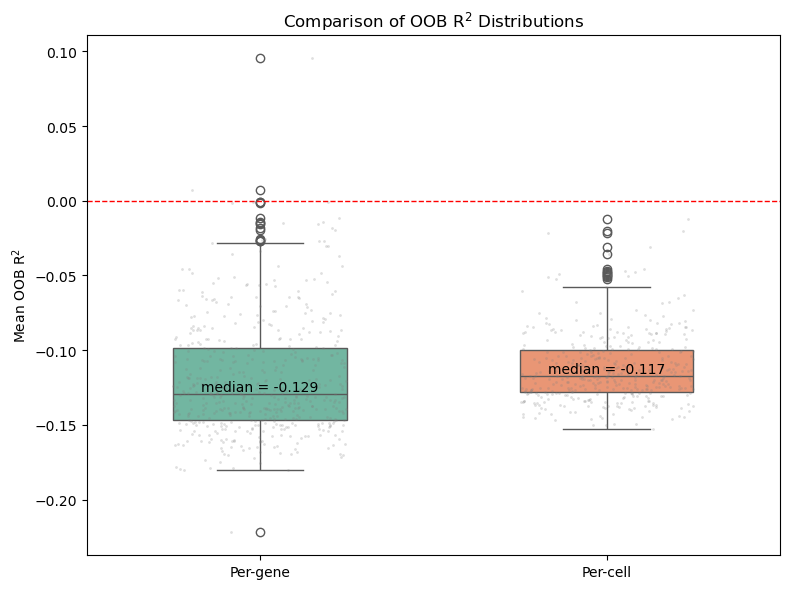

In [63]:
plt.style.use('default')
gene_r2 = oob_df.mean(axis=0)
cell_r2 = oob_df.mean(axis=1)

compare_df = pd.DataFrame({
    "R2": np.concatenate([gene_r2.values, cell_r2.values]),
    "Type": (["Per-gene"] * len(gene_r2)) +
            (["Per-cell"] * len(cell_r2))
})

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=compare_df,
    x="Type",
    y="R2",
    palette="Set2",
    width=0.5,
    ax=ax
)

sns.stripplot(
    data=compare_df,
    x="Type",
    y="R2",
    color="gray",
    alpha=0.25,
    size=2,
    jitter=0.25,
    ax=ax
)

ax.axhline(0, color="red", linestyle="--", linewidth=1)

ax.set_title("Comparison of OOB R$^2$ Distributions")
ax.set_xlabel("")
ax.set_ylabel("Mean OOB R$^2$")

gene_median = gene_r2.median()
cell_median = cell_r2.median()

ax.text(
    0,
    gene_median,
    f"median = {gene_median:.3f}",
    ha="center",
    va="bottom",
    fontsize=10
)

ax.text(
    1,
    cell_median,
    f"median = {cell_median:.3f}",
    ha="center",
    va="bottom",
    fontsize=10
)

plt.tight_layout()
plt.savefig("oob_r2_comparison_boxplot.png", dpi=150)
plt.show()

In [64]:
networks = np.load(f"output/{DATASET}_networks_seed42.npy")

In [65]:
gene_r2 = oob_df.mean(axis=0)
cell_r2 = oob_df.mean(axis=1)

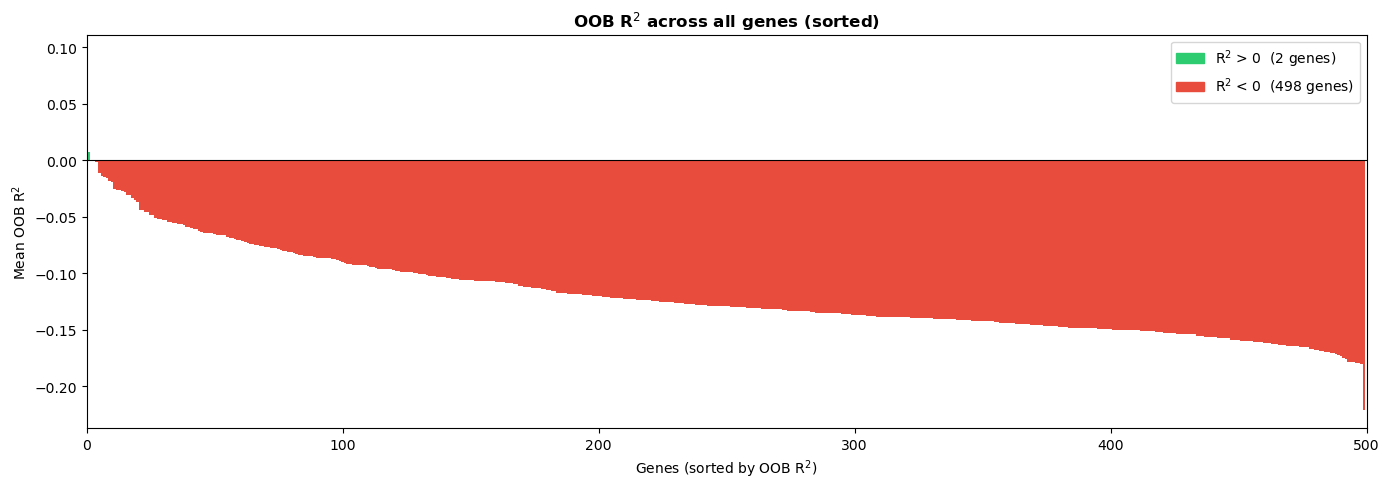

In [66]:
fig, ax = plt.subplots(figsize=(14, 5))

gene_r2_sorted = gene_r2.sort_values(ascending=False).reset_index(drop=True)

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in gene_r2_sorted]

ax.bar(range(len(gene_r2_sorted)), gene_r2_sorted.values, color=colors, width=1.0, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Genes (sorted by OOB R$^2$)")
ax.set_ylabel("Mean OOB R$^2$")
ax.set_title("OOB R$^2$ across all genes (sorted)", fontweight="bold")
ax.set_xlim(0, len(gene_r2_sorted))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ecc71", label=f"R$^2$ > 0  ({(gene_r2 > 0).sum()} genes)"),
    Patch(color="#e74c3c", label=f"R$^2$ < 0  ({(gene_r2 < 0).sum()} genes)"),
], loc="upper right")

plt.tight_layout()
plt.savefig("oob_r2_all_genes.png", dpi=150, bbox_inches="tight")
plt.show()

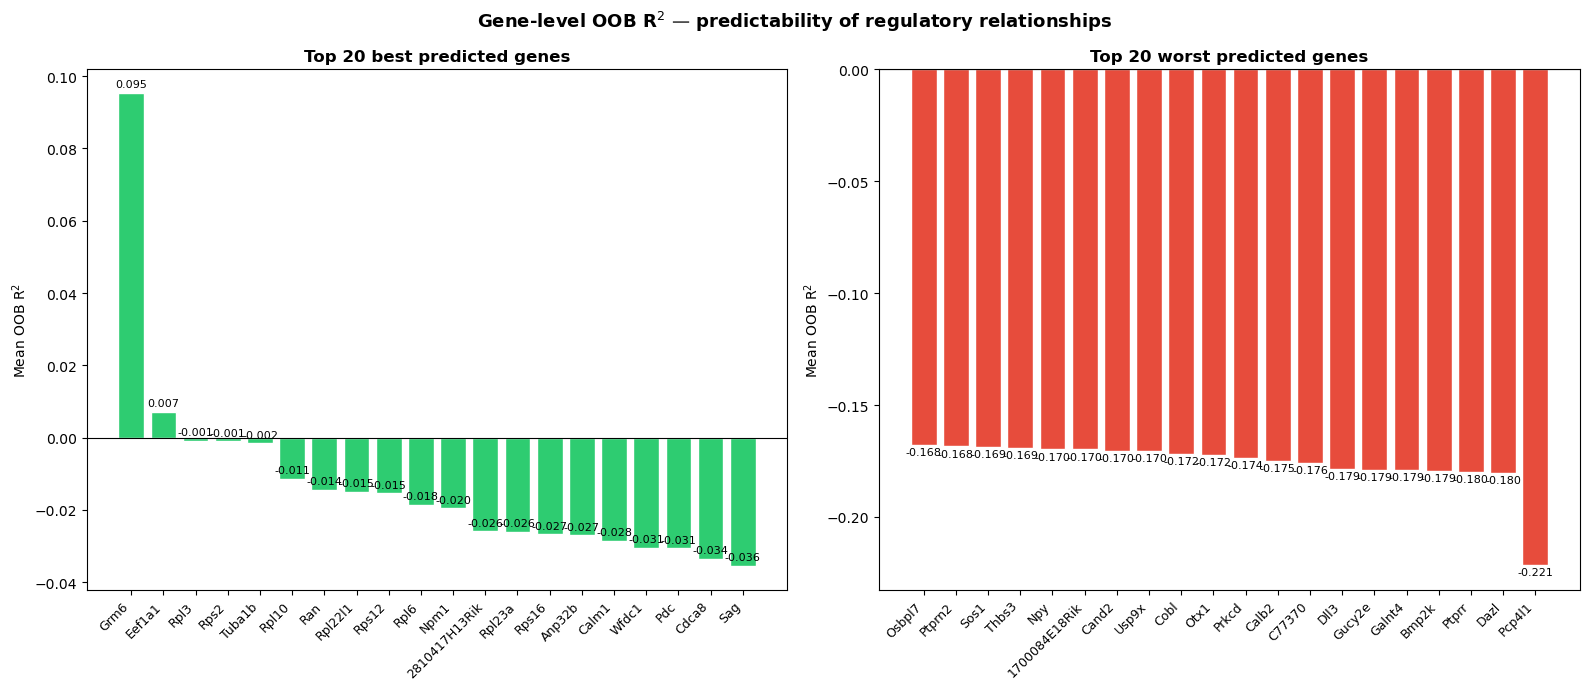

Genes with R$^2$ > 0 : 2 / 500
Genes with R$^2$ < 0 : 498 / 500


In [67]:
top_n = 20
best  = gene_r2.sort_values(ascending=False).head(top_n)
worst = gene_r2.sort_values(ascending=False).tail(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

bars = axes[0].bar(range(len(best)), best.values, color="#2ecc71", edgecolor="white")
axes[0].set_xticks(range(len(best)))
axes[0].set_xticklabels(best.index, fontsize=9, rotation=45, ha="right")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Mean OOB R$^2$")
axes[0].set_title(f"Top {top_n} best predicted genes", fontweight="bold")

for bar, val in zip(bars, best.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)

bars = axes[1].bar(range(len(worst)), worst.values, color="#e74c3c", edgecolor="white")
axes[1].set_xticks(range(len(worst)))
axes[1].set_xticklabels(worst.index, fontsize=9, rotation=45, ha="right")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Mean OOB R$^2$")
axes[1].set_title(f"Top {top_n} worst predicted genes", fontweight="bold")

for bar, val in zip(bars, worst.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val - 0.001,
                 f"{val:.3f}", ha="center", va="top", fontsize=8)

fig.suptitle("Gene-level OOB R$^2$ — predictability of regulatory relationships",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("oob_r2_per_gene.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Genes with R$^2$ > 0 : {(gene_r2 > 0).sum()} / {len(gene_r2)}")
print(f"Genes with R$^2$ < 0 : {(gene_r2 < 0).sum()} / {len(gene_r2)}")

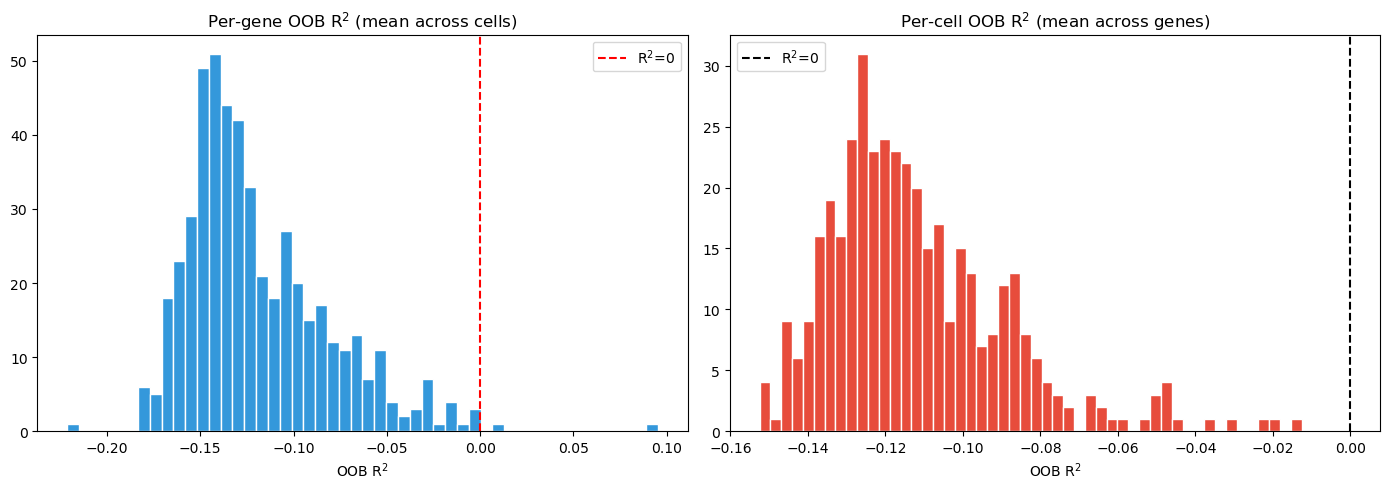

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(gene_r2.dropna(), bins=50, color="#3498db", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", label="R$^2$=0")
axes[0].set_title("Per-gene OOB R$^2$ (mean across cells)")
axes[0].set_xlabel("OOB R$^2$")
axes[0].legend()

axes[1].hist(cell_r2.dropna(), bins=50, color="#e74c3c", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", label="R$^2$=0")
axes[1].set_title("Per-cell OOB R$^2$ (mean across genes)")
axes[1].set_xlabel("OOB R$^2$")
axes[1].legend()

plt.tight_layout()
plt.savefig("oob_r2_distributions.png", dpi=150)
plt.show()

C:\Users\Edi\AppData\Local\Temp\ipykernel_32448\797034373.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = cell_r2_df.groupby("cell_type")["cell_r2"].median().sort_values(ascending=False).index
C:\Users\Edi\AppData\Local\Temp\ipykernel_32448\797034373.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cell_r2_df, x="cell_type", y="cell_r2",


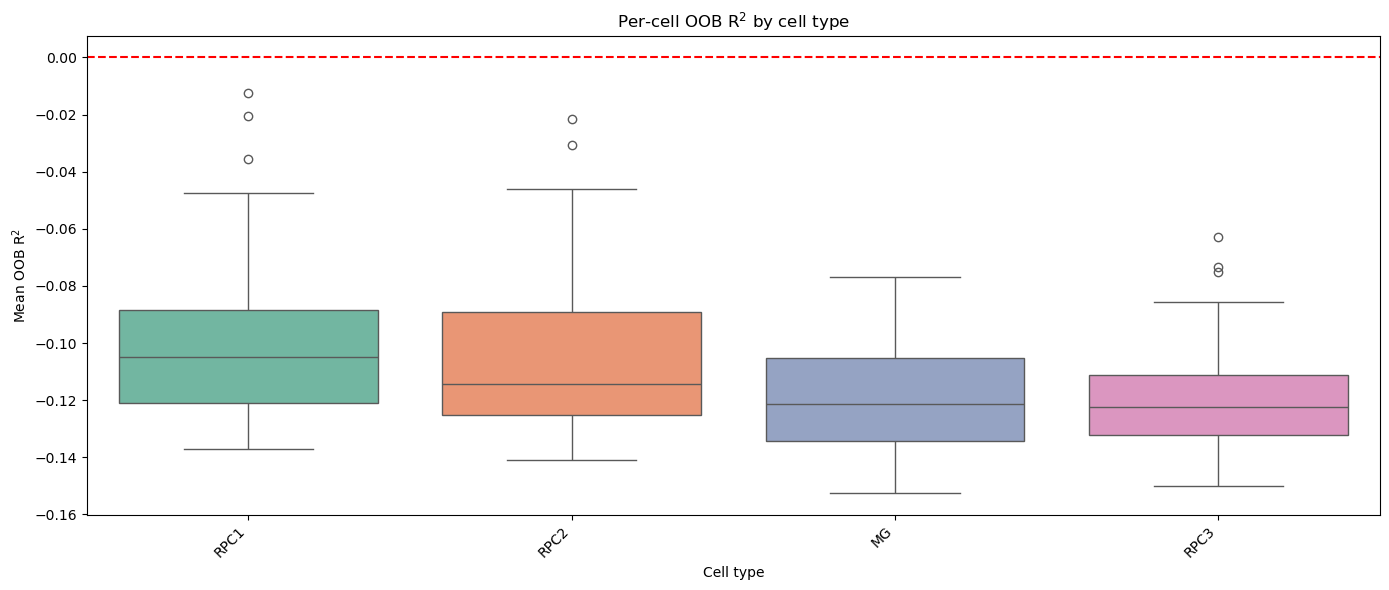

In [69]:
cell_type = rna.obs["cell_type"].copy()
cell_type[cell_type.isin(["nan", "None", "<NA>"])] = np.nan

cell_r2_df = pd.DataFrame({
    "cell_r2":   cell_r2.values,
    "cell_type": cell_type.values,
})

order = cell_r2_df.groupby("cell_type")["cell_r2"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=cell_r2_df, x="cell_type", y="cell_r2",
            order=order, ax=ax, palette="Set2")
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Per-cell OOB R$^2$ by cell type")
ax.set_xlabel("Cell type")
ax.set_ylabel("Mean OOB R$^2$")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("oob_r2_by_celltype.png", dpi=150)
plt.show()

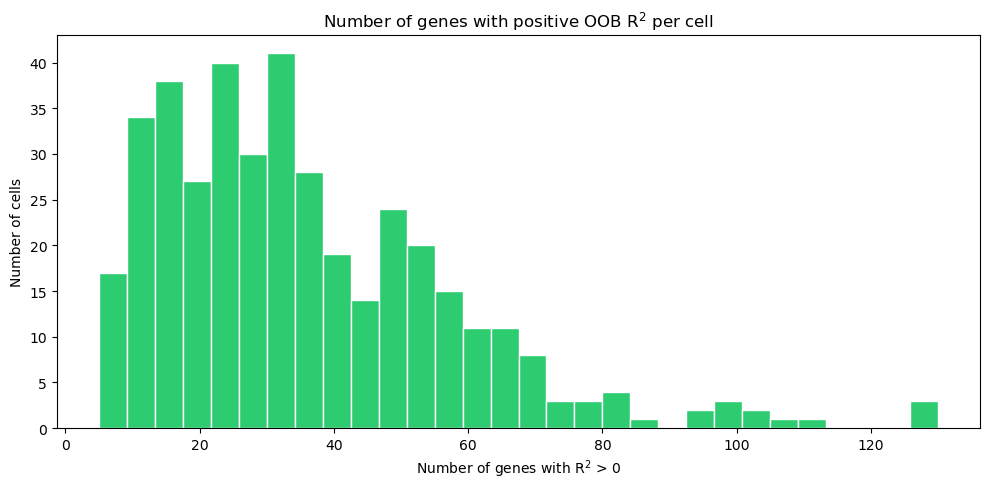

In [70]:
n_positive = (oob_df > 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(n_positive, bins=30, color="#2ecc71", edgecolor="white")
ax.set_title("Number of genes with positive OOB R$^2$ per cell")
ax.set_xlabel("Number of genes with R$^2$ > 0")
ax.set_ylabel("Number of cells")
plt.tight_layout()
plt.savefig("oob_positive_genes_per_cell.png", dpi=150)
plt.show()

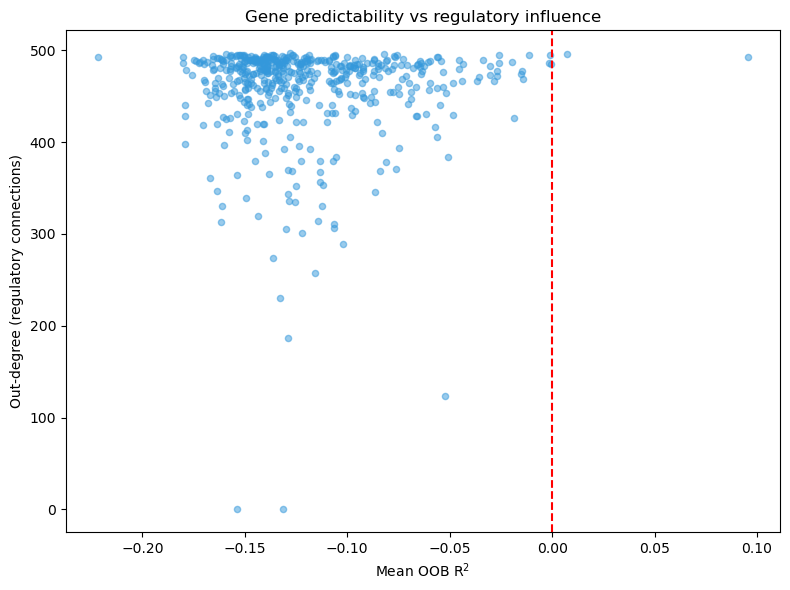

        gene  mean_oob_r2  out_degree
350     Grm6     0.095324         493
332   Eef1a1     0.007106         496
437     Rpl3    -0.000814         485
462     Rps2    -0.000972         495
440   Tuba1b    -0.001533         486
80     Rpl10    -0.011420         495
160      Ran    -0.014402         469
91   Rpl22l1    -0.014901         477
237    Rps12    -0.015362         474
158     Rpl6    -0.018498         426


In [71]:
networks   = np.load("output/seaad_paired_sub42_networks.npy")
mean_net   = networks.mean(axis=0)

out_degree = (mean_net > 0).sum(axis=0)   # (500,)

degree_df = pd.DataFrame({
    "gene":       rna.var_names,
    "mean_oob_r2": gene_r2.values,
    "out_degree":  out_degree,
}).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(degree_df["mean_oob_r2"], degree_df["out_degree"],
           alpha=0.5, s=20, color="#3498db")
ax.set_xlabel("Mean OOB R$^2$")
ax.set_ylabel("Out-degree (regulatory connections)")
ax.set_title("Gene predictability vs regulatory influence")
ax.axvline(0, color="red", linestyle="--")
plt.tight_layout()
plt.savefig("oob_vs_outdegree.png", dpi=150)
plt.show()

print(degree_df.sort_values("mean_oob_r2", ascending=False).head(10))

In [72]:
cell_r2 = oob_df.mean(axis=1)

cell_type = rna.obs["cell_type"].copy()
cell_type[cell_type.isin(["nan", "None", "<NA>"])] = np.nan

l5et_mask  = cell_type == "RPC1"
l5et_r2    = cell_r2[l5et_mask]
l5et_idx   = np.where(l5et_mask)[0]

print(f"L5 ET cells: {l5et_mask.sum()}")
print(l5et_r2.describe())

q_high = l5et_r2.quantile(0.90)
q_low  = l5et_r2.quantile(0.10)

high_mask = l5et_r2 >= q_high
low_mask  = l5et_r2 <= q_low

high_idx = l5et_idx[high_mask.values]
low_idx  = l5et_idx[low_mask.values]

print(f"High accuracy cells (top 10%): {len(high_idx)}, threshold R$^2$={q_high:.4f}")
print(f"Low accuracy cells (bot 10%):  {len(low_idx)}, threshold R$^2$={q_low:.4f}")

L5 ET cells: 100
count    100.000000
mean      -0.101505
std        0.024714
min       -0.137158
25%       -0.120889
50%       -0.104978
75%       -0.088356
max       -0.012543
dtype: float64
High accuracy cells (top 10%): 10, threshold R$^2$=-0.0765
Low accuracy cells (bot 10%):  10, threshold R$^2$=-0.1270


In [73]:
print(f"L5 ET cells total: {l5et_mask.sum()}")
print(l5et_r2.sort_values(ascending=False).head(10))
print("...")
print(l5et_r2.sort_values(ascending=True).head(10))

L5 ET cells total: 100
cell_166   -0.012543
cell_169   -0.020520
cell_179   -0.035407
cell_187   -0.047456
cell_154   -0.048195
cell_134   -0.051245
cell_140   -0.052062
cell_120   -0.064783
cell_142   -0.068441
cell_110   -0.074921
dtype: float64
...
cell_159   -0.137158
cell_104   -0.136473
cell_184   -0.135164
cell_164   -0.131549
cell_123   -0.130159
cell_103   -0.128965
cell_162   -0.128505
cell_107   -0.128367
cell_167   -0.127854
cell_185   -0.127292
dtype: float64


High accuracy cells: 1
Low accuracy cells : 1

High R$^2$ values: [-0.01254284]
Low R$^2$ values : [-0.13715788]


C:\Users\Edi\AppData\Local\Temp\ipykernel_32448\230108017.py:41: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pval = mannwhitneyu(high_corrs, low_corrs, alternative="greater")
C:\Users\Edi\AppData\Local\Temp\ipykernel_32448\230108017.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([high_corrs, low_corrs], labels=["High accuracy", "Low accuracy"],


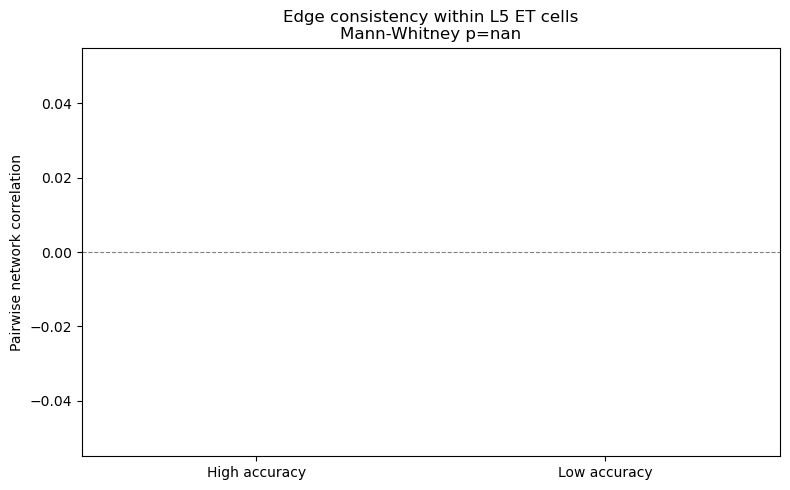

C:\Users\Edi\AppData\Local\Temp\ipykernel_32448\230108017.py:56: RuntimeWarning: Mean of empty slice.
  print(f"High accuracy mean correlation: {high_corrs.mean():.4f}")
D:\Edi\TU Delft\Research Project\bsc-screni\.pixi\envs\default\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Edi\AppData\Local\Temp\ipykernel_32448\230108017.py:57: RuntimeWarning: Mean of empty slice.
  print(f"Low accuracy mean correlation:  {low_corrs.mean():.4f}")


High accuracy mean correlation: nan
Low accuracy mean correlation:  nan


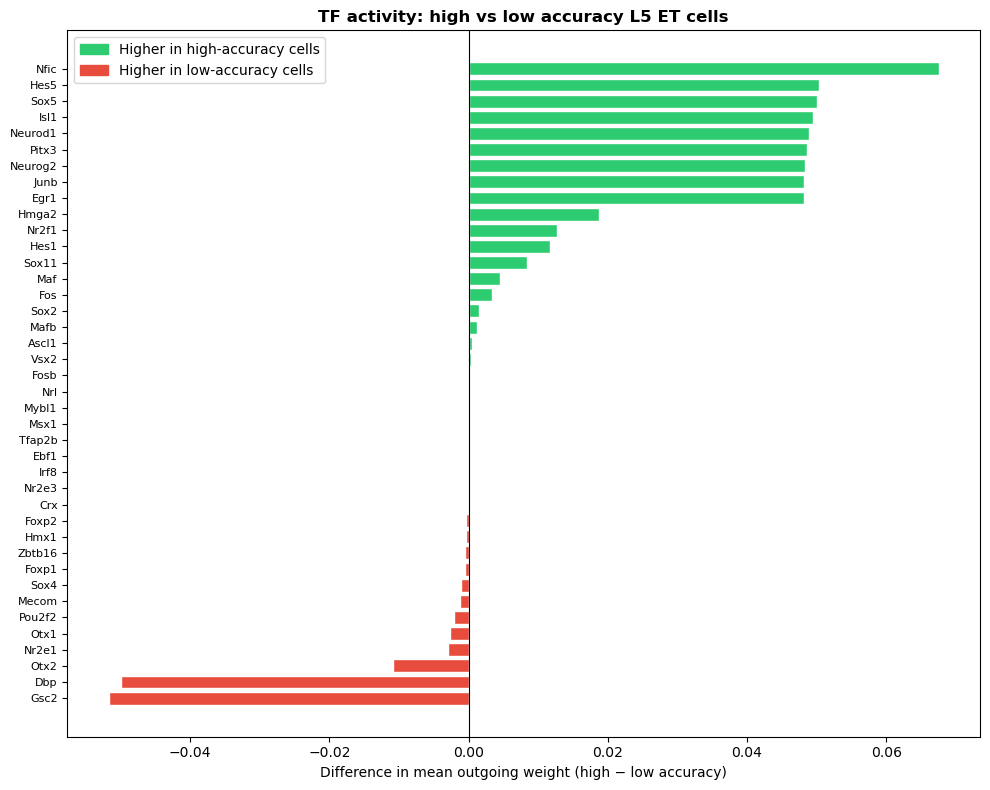


Top TFs more active in HIGH accuracy cells:
         TF  high_activity  low_activity      diff
43     Nfic       0.067515      0.000000  0.067515
42     Hes5       0.050391      0.000000  0.050391
32     Sox5       0.050000      0.000000  0.050000
24     Isl1       0.049510      0.000000  0.049510
35  Neurod1       0.048906      0.000000  0.048906
6     Pitx3       0.048679      0.000000  0.048679
27  Neurog2       0.048358      0.000000  0.048358
22     Junb       0.048227      0.000000  0.048227
33     Egr1       0.048160      0.000000  0.048160
36    Hmga2       0.073958      0.055283  0.018675

Top TFs more active in LOW accuracy cells:
        TF  high_activity  low_activity      diff
21  Zbtb16       0.047910      0.048363 -0.000453
40   Foxp1       0.049058      0.049616 -0.000558
41    Sox4       0.073067      0.074103 -0.001036
3    Mecom       0.049087      0.050280 -0.001193
26  Pou2f2       0.048897      0.051005 -0.002108
11    Otx1       0.049064      0.051759 -0.002695


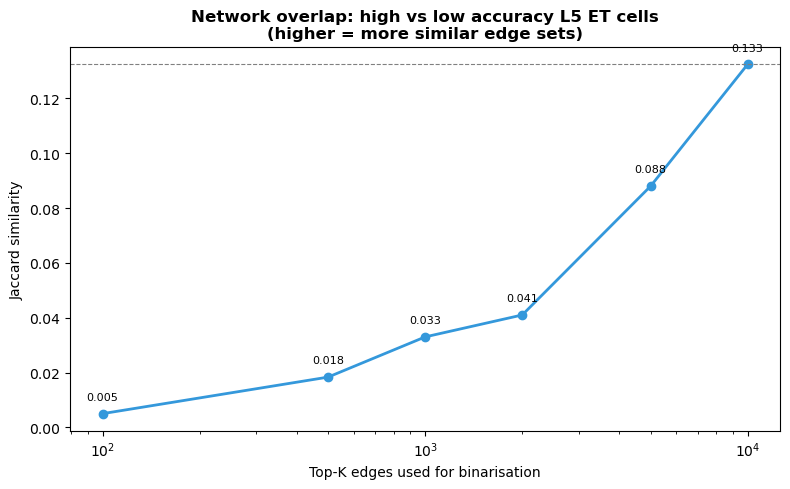

In [74]:
from scipy.stats import mannwhitneyu


networks = np.load(f"output/{DATASET}_networks.npy")
gene_names = rna.var_names.tolist()
gene_to_idx = {g: i for i, g in enumerate(gene_names)}

labels   = pd.read_csv(f"{BASE}_gene_labels.csv")
tf_genes = set(labels[labels["type"] == "TF"]["gene"])
tf_idxs  = [i for i, g in enumerate(gene_names) if g in tf_genes]

l5et_r2_sorted = l5et_r2.sort_values(ascending=False)

high_cells = l5et_r2_sorted.head(1).index
low_cells  = l5et_r2_sorted.tail(1).index

high_idx = np.where(rna.obs_names.isin(high_cells))[0]
low_idx  = np.where(rna.obs_names.isin(low_cells))[0]

high_networks = networks[high_idx]
low_networks  = networks[low_idx]

print(f"High accuracy cells: {len(high_idx)}")
print(f"Low accuracy cells : {len(low_idx)}")
print(f"\nHigh R$^2$ values: {l5et_r2[high_cells].values}")
print(f"Low R$^2$ values : {l5et_r2[low_cells].values}")

def pairwise_correlations(nets):
    n = len(nets)
    flat = nets.reshape(n, -1)
    corrs = []
    for i in range(n):
        for j in range(i+1, n):
            c = np.corrcoef(flat[i], flat[j])[0, 1]
            corrs.append(c)
    return np.array(corrs)

high_corrs = pairwise_correlations(high_networks)
low_corrs  = pairwise_correlations(low_networks)

stat, pval = mannwhitneyu(high_corrs, low_corrs, alternative="greater")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([high_corrs, low_corrs], labels=["High accuracy", "Low accuracy"],
           patch_artist=True,
           boxprops=dict(facecolor="#2ecc71", alpha=0.7),
           medianprops=dict(color="black", linewidth=2))
ax.set_ylabel("Pairwise network correlation")
ax.set_title("Edge consistency within L5 ET cells\n"
             f"Mann-Whitney p={pval:.4f}")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("l5et_edge_consistency.png", dpi=150)
plt.show()

print(f"High accuracy mean correlation: {high_corrs.mean():.4f}")
print(f"Low accuracy mean correlation:  {low_corrs.mean():.4f}")


high_mean_net = high_networks.mean(axis=0)
low_mean_net  = low_networks.mean(axis=0)

tf_activity = []
for tf in tf_genes:
    if tf not in gene_to_idx:
        continue
    idx = gene_to_idx[tf]
    high_out = high_mean_net[:, idx].sum()
    low_out  = low_mean_net[:, idx].sum()
    tf_activity.append({
        "TF":         tf,
        "high_activity": high_out,
        "low_activity":  low_out,
        "diff":          high_out - low_out,
    })

tf_df = pd.DataFrame(tf_activity).sort_values("diff", ascending=False)

top_tf    = tf_df.head(20)
bottom_tf = tf_df.tail(20)
plot_tf   = pd.concat([top_tf, bottom_tf])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in plot_tf["diff"]]
ax.barh(range(len(plot_tf)), plot_tf["diff"].values, color=colors, edgecolor="white")
ax.set_yticks(range(len(plot_tf)))
ax.set_yticklabels(plot_tf["TF"].values, fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Difference in mean outgoing weight (high − low accuracy)")
ax.set_title("TF activity: high vs low accuracy L5 ET cells", fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ecc71", label="Higher in high-accuracy cells"),
    Patch(color="#e74c3c", label="Higher in low-accuracy cells"),
])
plt.tight_layout()
plt.savefig("l5et_tf_activity.png", dpi=150)
plt.show()

print("\nTop TFs more active in HIGH accuracy cells:")
print(tf_df.head(10)[["TF", "high_activity", "low_activity", "diff"]].to_string())
print("\nTop TFs more active in LOW accuracy cells:")
print(tf_df.tail(10)[["TF", "high_activity", "low_activity", "diff"]].to_string())


def binarise(net, threshold=None, top_k=None):
    if top_k is not None:
        flat = net.flatten()
        threshold = np.sort(flat)[-top_k]
    return (net >= threshold).astype(int)

def jaccard(a, b):
    intersection = (a & b).sum()
    union        = (a | b).sum()
    return intersection / union if union > 0 else 0.0

TOP_K = 1000
high_bin = binarise(high_mean_net, top_k=TOP_K)
low_bin  = binarise(low_mean_net,  top_k=TOP_K)

j_score = jaccard(high_bin, low_bin)
print(f"\nJaccard similarity (top {TOP_K} edges): {j_score:.4f}")

top_ks  = [100, 500, 1000, 2000, 5000, 10000]
jaccards = [jaccard(binarise(high_mean_net, top_k=k),
                    binarise(low_mean_net,  top_k=k)) for k in top_ks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(top_ks, jaccards, marker="o", color="#3498db", linewidth=2)
ax.set_xlabel("Top-K edges used for binarisation")
ax.set_ylabel("Jaccard similarity")
ax.set_title("Network overlap: high vs low accuracy L5 ET cells\n"
             "(higher = more similar edge sets)", fontweight="bold")
ax.set_xscale("log")
ax.axhline(jaccards[-1], color="grey", linestyle="--", linewidth=0.8)
for k, j in zip(top_ks, jaccards):
    ax.text(k, j + 0.005, f"{j:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("l5et_jaccard.png", dpi=150)
plt.show()

In [75]:
cell_r2 = oob_df.mean(axis=1)
print(cell_r2.describe())
print(f"\nTop 10% threshold : {cell_r2.quantile(0.90):.4f}")
print(f"Bottom 10% threshold: {cell_r2.quantile(0.10):.4f}")
print(f"\nTop 5% threshold  : {cell_r2.quantile(0.95):.4f}")
print(f"Bottom 5% threshold : {cell_r2.quantile(0.05):.4f}")

count    400.000000
mean      -0.112057
std        0.023129
min       -0.152509
25%       -0.128009
50%       -0.117128
75%       -0.099829
max       -0.012543
dtype: float64

Top 10% threshold : -0.0842
Bottom 10% threshold: -0.1369

Top 5% threshold  : -0.0684
Bottom 5% threshold : -0.1411


In [76]:
print(f"Cells with R$^2$ > 0  : {(cell_r2 > 0).sum()}")
print(f"Cells with R$^2$ > 0.05: {(cell_r2 > 0.05).sum()}")
print(f"Cells with R$^2$ > 0.10: {(cell_r2 > 0.10).sum()}")

Cells with R$^2$ > 0  : 0
Cells with R$^2$ > 0.05: 0
Cells with R$^2$ > 0.10: 0


In [77]:
cell_r2 = oob_df.mean(axis=1)

q_high = cell_r2.quantile(0.90)
q_low  = cell_r2.quantile(0.10)

high_mask = cell_r2 >= q_high
low_mask  = cell_r2 <= q_low

high_idx = np.where(high_mask)[0]
low_idx  = np.where(low_mask)[0]

high_networks = networks[high_idx]
low_networks  = networks[low_idx]

print(f"High accuracy cells: {len(high_idx)}, mean R$^2$={cell_r2[high_mask].mean():.4f}")
print(f"Low accuracy cells : {len(low_idx)}, mean R$^2$={cell_r2[low_mask].mean():.4f}")

cell_type = rna.obs["cell_type"].copy()
cell_type[cell_type.isin(["nan", "None", "<NA>"])] = np.nan

print("\nCell type distribution in HIGH accuracy group:")
print(cell_type[high_mask].value_counts())

print("\nCell type distribution in LOW accuracy group:")
print(cell_type[low_mask].value_counts())

High accuracy cells: 40, mean R$^2$=-0.0630
Low accuracy cells : 40, mean R$^2$=-0.1422

Cell type distribution in HIGH accuracy group:
cell_type
RPC2    19
RPC1    17
RPC3     3
MG       1
Name: count, dtype: int64

Cell type distribution in LOW accuracy group:
cell_type
MG      21
RPC3    16
RPC2     2
RPC1     1
Name: count, dtype: int64


C:\Users\Edi\AppData\Local\Temp\ipykernel_32448\1888178272.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([high_corrs, low_corrs],


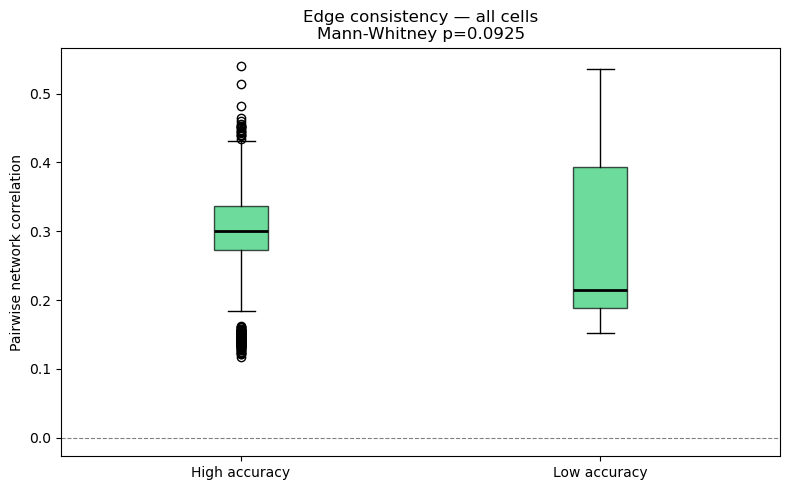

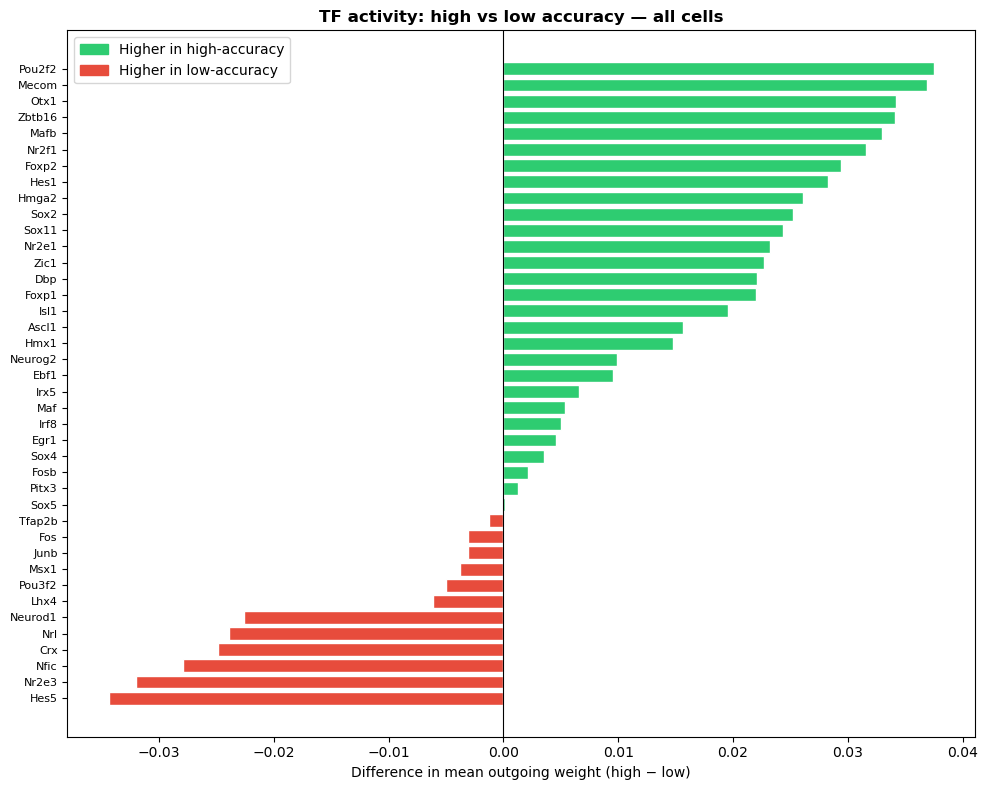

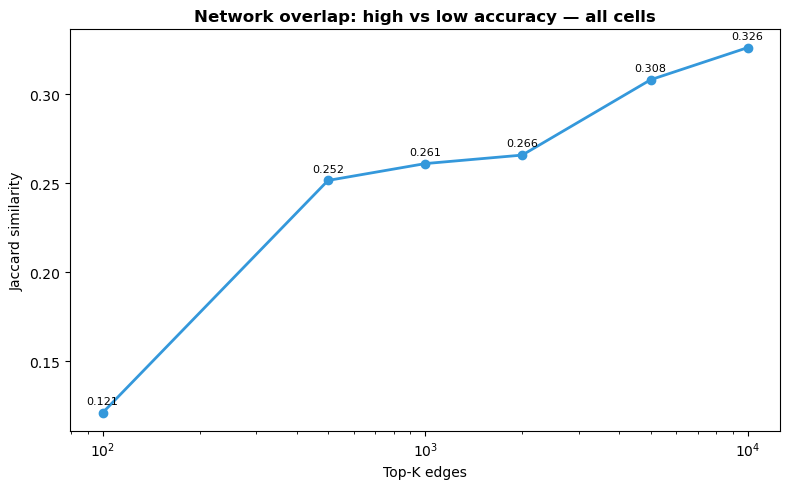

In [78]:
high_networks = networks[high_idx]
low_networks  = networks[low_idx]

high_mean_net = high_networks.mean(axis=0)
low_mean_net  = low_networks.mean(axis=0)

high_corrs = pairwise_correlations(high_networks)
low_corrs  = pairwise_correlations(low_networks)

stat, pval = mannwhitneyu(high_corrs, low_corrs, alternative="greater")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([high_corrs, low_corrs],
           labels=["High accuracy", "Low accuracy"],
           patch_artist=True,
           boxprops=dict(facecolor="#2ecc71", alpha=0.7),
           medianprops=dict(color="black", linewidth=2))
ax.set_ylabel("Pairwise network correlation")
ax.set_title(f"Edge consistency — all cells\nMann-Whitney p={pval:.4f}")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("optA_edge_consistency.png", dpi=150)
plt.show()

tf_activity = []
for tf in tf_genes:
    if tf not in gene_to_idx:
        continue
    idx = gene_to_idx[tf]
    high_out = high_mean_net[:, idx].sum()
    low_out  = low_mean_net[:, idx].sum()
    tf_activity.append({
        "TF":            tf,
        "high_activity": high_out,
        "low_activity":  low_out,
        "diff":          high_out - low_out,
    })

tf_df = pd.DataFrame(tf_activity).sort_values("diff", ascending=False)
top_tf   = tf_df.head(20)
bot_tf   = tf_df.tail(20)
plot_tf  = pd.concat([top_tf, bot_tf])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in plot_tf["diff"]]
ax.barh(range(len(plot_tf)), plot_tf["diff"].values, color=colors, edgecolor="white")
ax.set_yticks(range(len(plot_tf)))
ax.set_yticklabels(plot_tf["TF"].values, fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Difference in mean outgoing weight (high − low)")
ax.set_title("TF activity: high vs low accuracy — all cells", fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ecc71", label="Higher in high-accuracy"),
    Patch(color="#e74c3c", label="Higher in low-accuracy"),
])
plt.tight_layout()
plt.savefig("optA_tf_activity.png", dpi=150)
plt.show()

top_ks   = [100, 500, 1000, 2000, 5000, 10000]
jaccards = [jaccard(binarise(high_mean_net, top_k=k),
                    binarise(low_mean_net,  top_k=k)) for k in top_ks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(top_ks, jaccards, marker="o", color="#3498db", linewidth=2)
ax.set_xlabel("Top-K edges")
ax.set_ylabel("Jaccard similarity")
ax.set_title("Network overlap: high vs low accuracy — all cells", fontweight="bold")
ax.set_xscale("log")
for k, j in zip(top_ks, jaccards):
    ax.text(k, j + 0.005, f"{j:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("optA_jaccard.png", dpi=150)
plt.show()

In [79]:
df_pr = pd.read_csv("output/precision_recall_k0.csv", index_col=0)

In [80]:
print(df_pr.head())
print(df_pr.shape)
print(df_pr.columns)

  scNetwork_type  precision    recall
0            CSN   0.023229  0.116859
1            CSN   0.019916  0.077680
2            CSN   0.023092  0.108379
3            CSN   0.021055  0.081411
4            CSN   0.026123  0.171811
(800, 3)
Index(['scNetwork_type', 'precision', 'recall'], dtype='object')


In [81]:
df_pr = df_pr[df_pr["scNetwork_type"] == "wScReNI"].copy()
df_pr = df_pr[["precision", "recall"]]

In [82]:
df_pr = df_pr.sort_index()

In [83]:
print(df_pr.head())
print(df_pr.shape)
print(df_pr.columns)

   precision    recall
0   0.023229  0.116859
1   0.019916  0.077680
2   0.023092  0.108379
3   0.021055  0.081411
4   0.026123  0.171811
(400, 2)
Index(['precision', 'recall'], dtype='object')


In [84]:
df_pr.describe()

,precision,recall
count,400.000000,400.000000
mean,0.031814,0.178360
std,0.005798,0.050445
min,0.017932,0.070217
25%,0.028856,0.153621
50%,0.033231,0.184023
75%,0.035664,0.214467
max,0.048416,0.281038


In [85]:
df = df_pr.copy()
cell_r2.index = df.index
df["rf_r2"] = cell_r2


In [86]:
print(df.head())
print(df.shape)
print(df.columns)

   precision    recall     rf_r2
0   0.023229  0.116859 -0.098477
1   0.019916  0.077680 -0.152509
2   0.023092  0.108379 -0.112454
3   0.021055  0.081411 -0.133888
4   0.026123  0.171811 -0.109528
(400, 3)
Index(['precision', 'recall', 'rf_r2'], dtype='object')


In [87]:
df = df.dropna(subset=["rf_r2", "precision", "recall"]).copy()
df.head()

,precision,recall,rf_r2
0,0.023229,0.116859,-0.098477
1,0.019916,0.077680,-0.152509
2,0.023092,0.108379,-0.112454
3,0.021055,0.081411,-0.133888
4,0.026123,0.171811,-0.109528


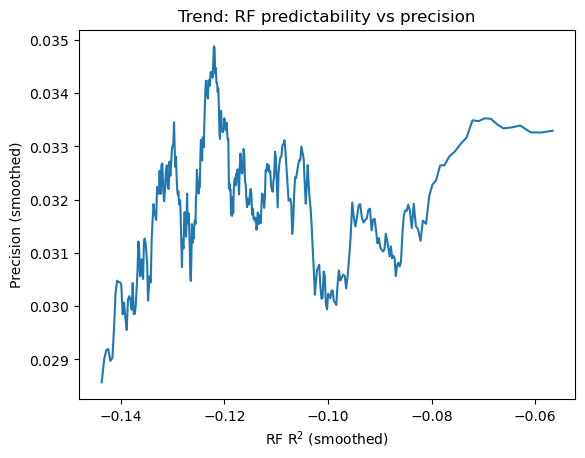

In [88]:
df_sorted = df.sort_values("rf_r2")

window = 30

smooth = df_sorted[["rf_r2", "precision", "recall"]].rolling(window).mean()

plt.figure()
plt.plot(smooth["rf_r2"], smooth["precision"])
plt.xlabel("RF R$^2$ (smoothed)")
plt.ylabel("Precision (smoothed)")
plt.title("Trend: RF predictability vs precision")
plt.show()

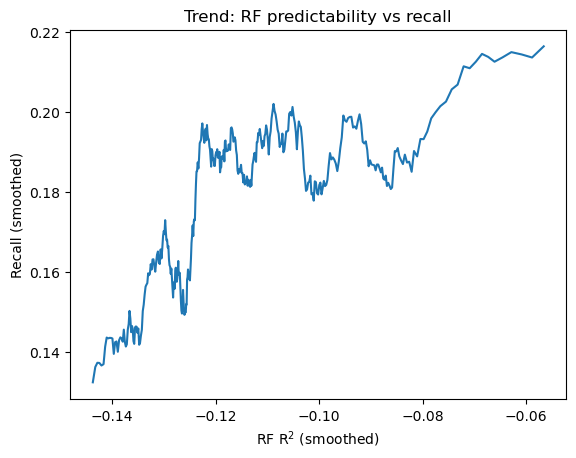

In [89]:
df_sorted = df.sort_values("rf_r2")

window = 30

smooth = df_sorted[["rf_r2", "precision", "recall"]].rolling(window).mean()

plt.figure()
plt.plot(smooth["rf_r2"], smooth["recall"])
plt.xlabel("RF R$^2$ (smoothed)")
plt.ylabel("Recall (smoothed)")
plt.title("Trend: RF predictability vs recall")
plt.show()

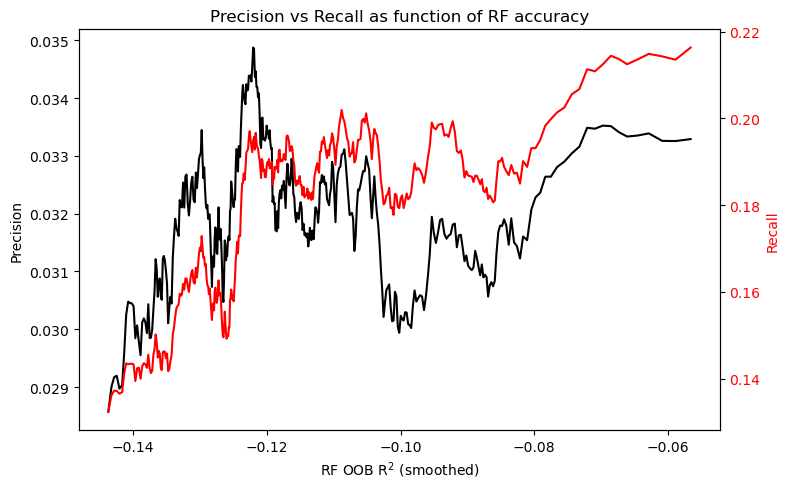

In [90]:
df_sorted = df.sort_values("rf_r2")
window = 30
smooth = df_sorted[["rf_r2", "precision", "recall"]].rolling(window).mean()

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(smooth["rf_r2"], smooth["precision"], color="black", label="Precision")
ax1.set_xlabel("RF OOB R$^2$ (smoothed)")
ax1.set_ylabel("Precision", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(smooth["rf_r2"], smooth["recall"], color="red", label="Recall")
ax2.set_ylabel("Recall", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Precision vs Recall as function of RF accuracy")

fig.tight_layout()
plt.show()

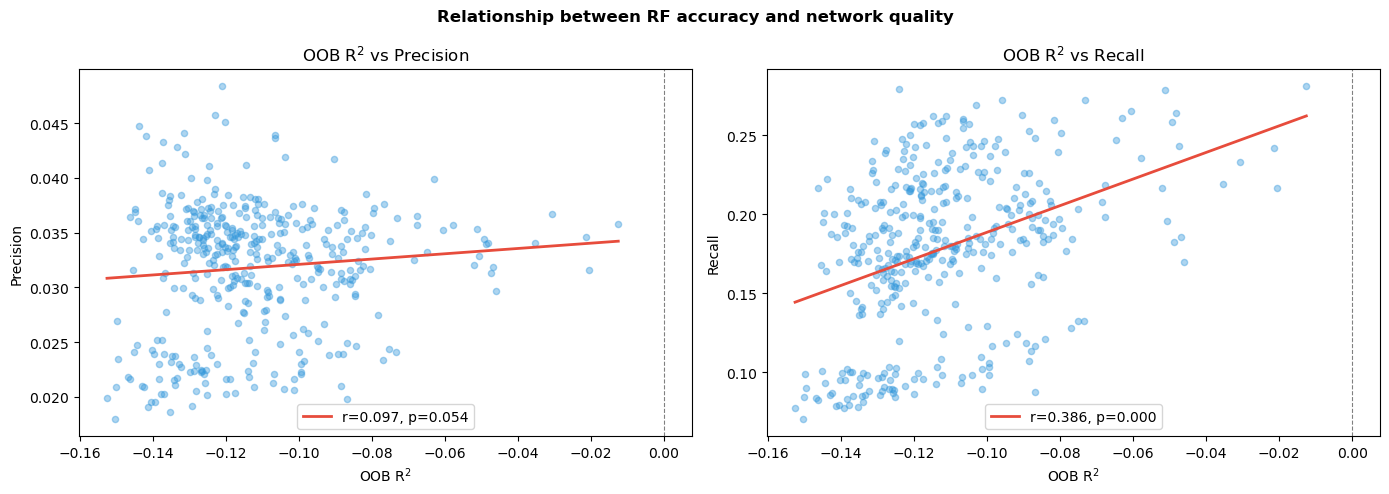

In [91]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["precision", "recall"]):
    ax.scatter(df["rf_r2"], df[metric], alpha=0.4, s=20, color="#3498db")

    slope, intercept, r, p, se = stats.linregress(df["rf_r2"], df[metric])
    x = np.linspace(df["rf_r2"].min(), df["rf_r2"].max(), 100)
    ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
            label=f"r={r:.3f}, p={p:.3f}")

    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xlabel("OOB R$^2$")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"OOB R$^2$ vs {metric.capitalize()}")
    ax.legend()

plt.suptitle("Relationship between RF accuracy and network quality", fontweight="bold")
plt.tight_layout()
plt.savefig("r2_vs_precision_recall.png", dpi=150)
plt.show()

In [92]:
print("Correlations with OOB R$^2$:")
print("-" * 40)
for metric in ["precision", "recall"]:
    pearson_r,  pearson_p  = stats.pearsonr(df["rf_r2"], df[metric])
    spearman_r, spearman_p = stats.spearmanr(df["rf_r2"], df[metric])
    print(f"\n{metric.capitalize()}:")
    print(f"  Pearson  r={pearson_r:.4f},  p={pearson_p:.4f}")
    print(f"  Spearman r={spearman_r:.4f}, p={spearman_p:.4f}")


Correlations with OOB R$^2$:
----------------------------------------

Precision:
  Pearson  r=0.0966,  p=0.0535
  Spearman r=0.0257, p=0.6085

Recall:
  Pearson  r=0.3857,  p=0.0000
  Spearman r=0.3909, p=0.0000


F1 vs OOB R$^2$:
  Pearson  r=0.1675, p=0.0008
  Spearman r=0.1074, p=0.0318


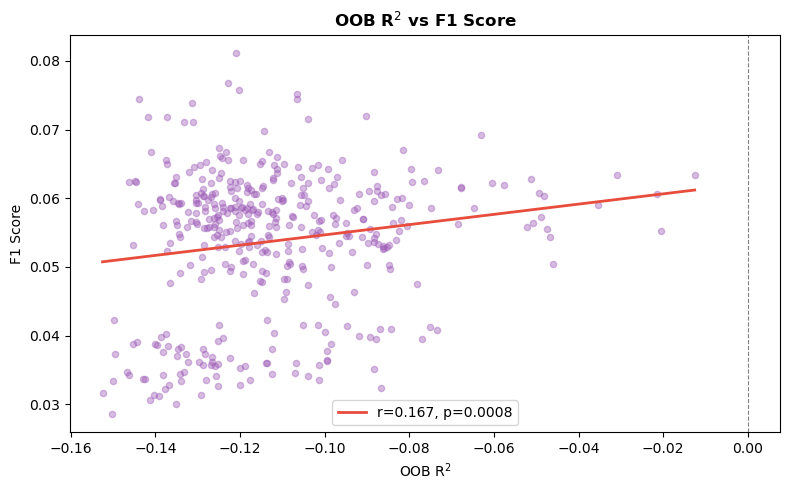

In [93]:
df["f1"] = 2 * (df["precision"] * df["recall"]) / (df["precision"] + df["recall"])

pearson_r,  pearson_p  = stats.pearsonr(df["rf_r2"], df["f1"])
spearman_r, spearman_p = stats.spearmanr(df["rf_r2"], df["f1"])
print(f"F1 vs OOB R$^2$:")
print(f"  Pearson  r={pearson_r:.4f}, p={pearson_p:.4f}")
print(f"  Spearman r={spearman_r:.4f}, p={spearman_p:.4f}")

# Add to scatter plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["rf_r2"], df["f1"], alpha=0.4, s=20, color="#9b59b6")
slope, intercept, r, p, se = stats.linregress(df["rf_r2"], df["f1"])
x = np.linspace(df["rf_r2"].min(), df["rf_r2"].max(), 100)
ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
        label=f"r={r:.3f}, p={p:.4f}")
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("OOB R$^2$")
ax.set_ylabel("F1 Score")
ax.set_title("OOB R$^2$ vs F1 Score", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("r2_vs_f1.png", dpi=150)
plt.show()

In [94]:
median_r2 = df["rf_r2"].median()
high_r2   = df[df["rf_r2"] >= median_r2]
low_r2    = df[df["rf_r2"] <  median_r2]

print(f"\nMedian R$^2$ split: {median_r2:.4f}")
print(f"High R$^2$ cells ({len(high_r2)}): mean precision={high_r2['precision'].mean():.4f}, mean recall={high_r2['recall'].mean():.4f}")
print(f"Low R$^2$  cells ({len(low_r2)}):  mean precision={low_r2['precision'].mean():.4f},  mean recall={low_r2['recall'].mean():.4f}")

for metric in ["precision", "recall"]:
    stat, p = stats.mannwhitneyu(high_r2[metric], low_r2[metric], alternative="two-sided")
    print(f"Mann-Whitney {metric}: p={p:.4f}")


Median R$^2$ split: -0.1171
High R$^2$ cells (200): mean precision=0.0319, mean recall=0.1934
Low R$^2$  cells (200):  mean precision=0.0317,  mean recall=0.1634
Mann-Whitney precision: p=0.7090
Mann-Whitney recall: p=0.0000


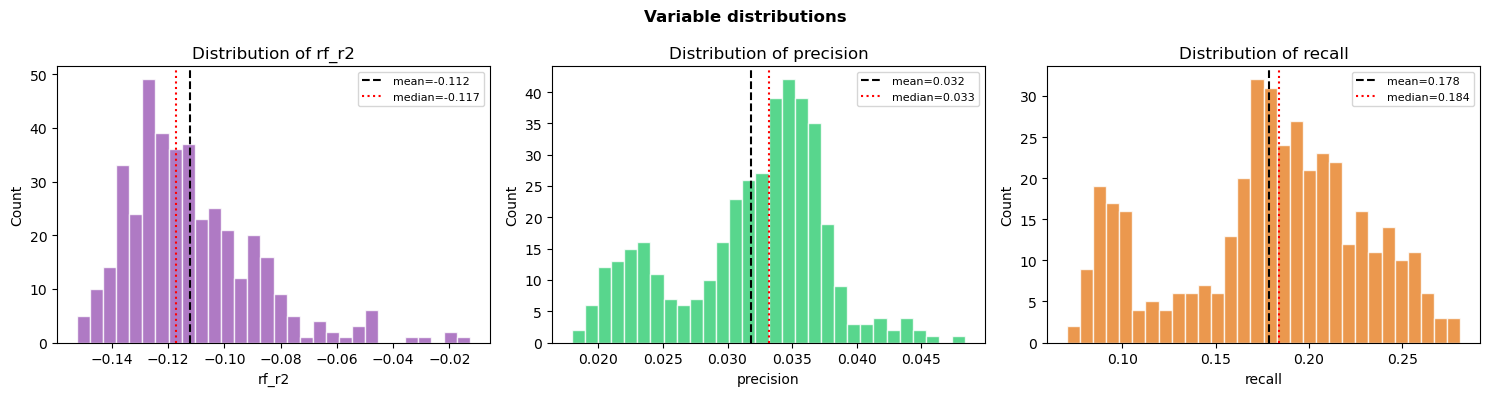

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["rf_r2", "precision", "recall"],
                           ["#9b59b6", "#2ecc71", "#e67e22"]):
    ax.hist(df[col], bins=30, color=color, edgecolor="white", alpha=0.8)
    ax.axvline(df[col].mean(),   color="black", linestyle="--", label=f"mean={df[col].mean():.3f}")
    ax.axvline(df[col].median(), color="red",   linestyle=":",  label=f"median={df[col].median():.3f}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {col}")
    ax.legend(fontsize=8)

plt.suptitle("Variable distributions", fontweight="bold")
plt.tight_layout()
plt.savefig("distributions.png", dpi=150)
plt.show()

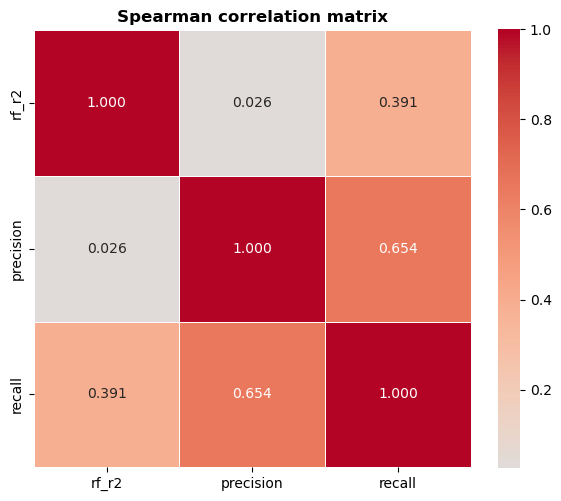

In [96]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[["rf_r2", "precision", "recall"]].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Spearman correlation matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

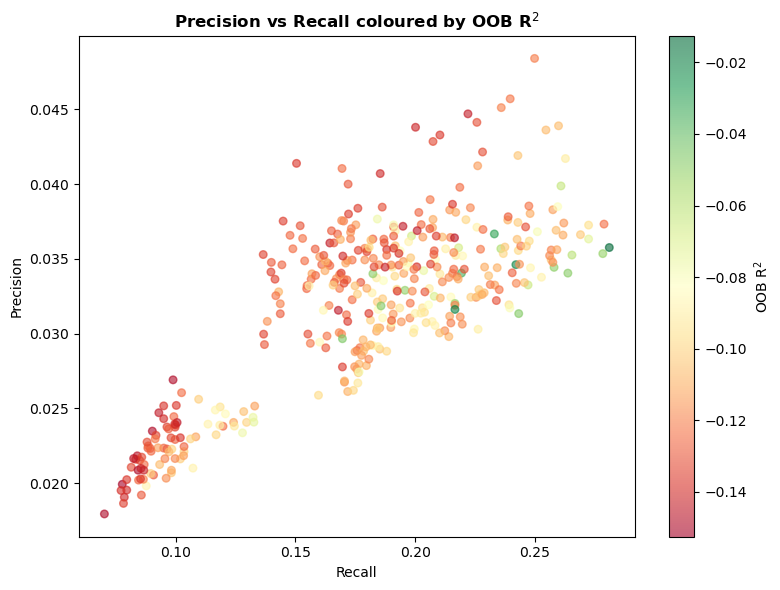

In [97]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df["recall"], df["precision"],
                c=df["rf_r2"], cmap="RdYlGn",
                alpha=0.6, s=30)
plt.colorbar(sc, ax=ax, label="OOB R$^2$")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision vs Recall coloured by OOB R$^2$", fontweight="bold")
plt.tight_layout()
plt.savefig("precision_recall_r2.png", dpi=150)
plt.show()

Spearman R$^2$ vs density: r=0.5488, p=7.67e-33


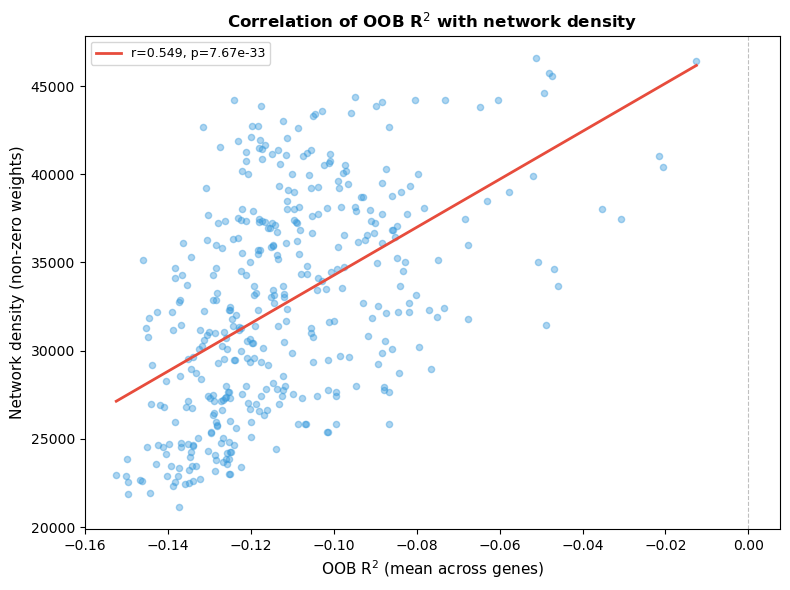

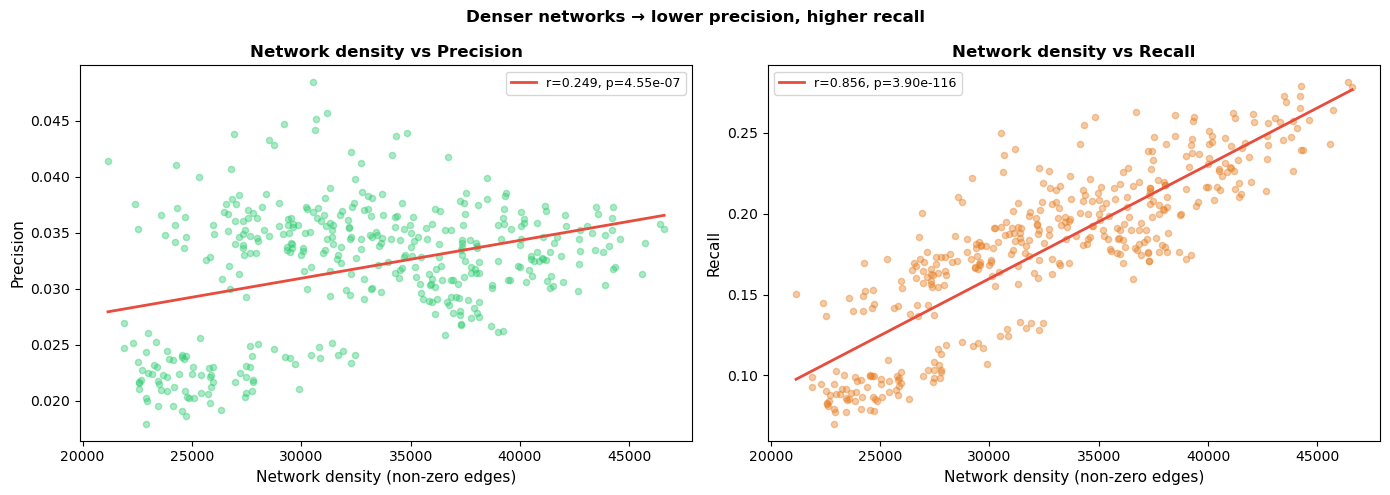

In [98]:
density = np.array([(networks[i] > 0).sum() for i in range(len(networks))])

r, p = stats.spearmanr(cell_r2.values, density)
p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"
print(f"Spearman R$^2$ vs density: r={r:.4f}, p={p_str}")

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(cell_r2.values, density, alpha=0.4, s=20, color="#3498db")

slope, intercept, _, _, _ = stats.linregress(cell_r2.values, density)
x = np.linspace(cell_r2.min(), cell_r2.max(), 100)
ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
        label=f"r={r:.3f}, p={p_str}")

ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("OOB R$^2$ (mean across genes)", fontsize=11)
ax.set_ylabel("Network density (non-zero weights)", fontsize=11)
ax.set_title("Correlation of OOB R$^2$ with network density", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("r2_vs_density.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, color in zip(axes, ["precision", "recall"], ["#2ecc71", "#e67e22"]):
    r_d, p_d = stats.spearmanr(density, df[metric])
    p_str_d  = f"{p_d:.2e}" if p_d < 0.0001 else f"{p_d:.4f}"

    ax.scatter(density, df[metric], alpha=0.4, s=20, color=color)

    slope, intercept, _, _, _ = stats.linregress(density, df[metric])
    x = np.linspace(density.min(), density.max(), 100)
    ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
            label=f"r={r_d:.3f}, p={p_str_d}")

    ax.set_xlabel("Network density (non-zero edges)", fontsize=11)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f"Network density vs {metric.capitalize()}", fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("Denser networks → lower precision, higher recall",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("density_vs_precision_recall.png", dpi=150)
plt.show()

In [99]:
genes = rna.var_names.tolist()

X = rna.X.toarray() if sp.issparse(rna.X) else rna.X
expr_df = pd.DataFrame(
    X.T,
    index   = rna.var_names,
    columns = rna.obs_names,
)

In [100]:

mean_network = networks.mean(axis=0)


In [101]:
import networkx as nx

TOP_K = 500

all_in_degree    = np.zeros((len(networks), len(genes)))
all_out_degree   = np.zeros((len(networks), len(genes)))
all_betweenness  = np.zeros((len(networks), len(genes)))
all_pagerank     = np.zeros((len(networks), len(genes)))

gene_to_pos = {g: i for i, g in enumerate(genes)}

for cell_idx in range(len(networks)):
    net = networks[cell_idx]
    flat = net.flatten()
    threshold = np.sort(flat)[-TOP_K]

    G = nx.DiGraph()
    rows, cols = np.where(net >= threshold)
    for r, c in zip(rows, cols):
        if r != c:
            G.add_edge(genes[c], genes[r], weight=net[r, c])

    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    betw    = nx.betweenness_centrality(G, weight="weight")
    pr      = nx.pagerank(G, weight="weight") if G.number_of_edges() > 0 else {}

    for gene in G.nodes():
        pos = gene_to_pos[gene]
        all_in_degree[cell_idx, pos]   = in_deg.get(gene, 0)
        all_out_degree[cell_idx, pos]  = out_deg.get(gene, 0)
        all_betweenness[cell_idx, pos] = betw.get(gene, 0)
        all_pagerank[cell_idx, pos]    = pr.get(gene, 0)

in_degree   = dict(zip(genes, all_in_degree.mean(axis=0)))
out_degree  = dict(zip(genes, all_out_degree.mean(axis=0)))
betweenness = dict(zip(genes, all_betweenness.mean(axis=0)))
pagerank    = dict(zip(genes, all_pagerank.mean(axis=0)))

In [102]:
print("In-degree stats:", pd.Series(in_degree).describe())
print("Out-degree stats:", pd.Series(out_degree).describe())
print("Betweenness stats:", pd.Series(betweenness).describe())
print("Pagerank stats:", pd.Series(pagerank).describe())

print(f"\nGenes with non-zero in-degree: {(np.array(list(in_degree.values())) > 0).sum()} / 500")
print(f"Genes with non-zero out-degree: {(np.array(list(out_degree.values())) > 0).sum()} / 500")

In-degree stats: count    500.000000
mean       1.006805
std        3.376656
min        0.010000
25%        0.080000
50%        0.147500
75%        0.840625
max       55.897500
dtype: float64
Out-degree stats: count    500.000000
mean       1.006805
std        0.575732
min        0.037500
25%        0.617500
50%        0.948750
75%        1.310000
max        6.045000
dtype: float64
Betweenness stats: count    5.000000e+02
mean     3.132609e-04
std      1.354605e-03
min      2.705682e-07
25%      1.915505e-05
50%      4.842476e-05
75%      1.766210e-04
max      2.421878e-02
dtype: float64
Pagerank stats: count    500.000000
mean       0.002000
std        0.005506
min        0.000048
25%        0.000496
50%        0.000932
75%        0.001821
max        0.095776
dtype: float64

Genes with non-zero in-degree: 500 / 500
Genes with non-zero out-degree: 500 / 500


In [103]:
centrality_df = pd.DataFrame({
    "gene":        genes,
    "in_degree":   [in_degree.get(g, 0) for g in genes],
    "out_degree":  [out_degree.get(g, 0) for g in genes],
    "betweenness": [betweenness.get(g, 0) for g in genes],
    "pagerank":    [pagerank.get(g, 0) for g in genes],
    "gene_r2":     gene_r2.values,
})

for col in ["in_degree", "out_degree", "betweenness", "pagerank"]:
    r, p = stats.spearmanr(centrality_df["gene_r2"], centrality_df[col])
    print(f"Gene R$^2$ vs {col}: r={r:.4f}, p={p:.2e}")

Gene R$^2$ vs in_degree: r=0.4282, p=1.03e-23
Gene R$^2$ vs out_degree: r=-0.2340, p=1.20e-07
Gene R$^2$ vs betweenness: r=0.2342, p=1.18e-07
Gene R$^2$ vs pagerank: r=0.3926, p=7.11e-20


In [104]:
labels = pd.read_csv(f"{BASE}_gene_labels.csv")
gene_type_map = dict(zip(labels["gene"], labels["type"]))

centrality_df["type"] = centrality_df["gene"].map(gene_type_map)

tf_r2     = centrality_df[centrality_df["type"] == "TF"]["gene_r2"]
target_r2 = centrality_df[centrality_df["type"] == "target"]["gene_r2"]

stat, p = stats.mannwhitneyu(tf_r2, target_r2, alternative="two-sided")
print(f"TF vs target R$^2$: TF mean={tf_r2.mean():.4f}, Target mean={target_r2.mean():.4f}, p={p:.4f}")

TF vs target R$^2$: TF mean=-0.1280, Target mean=-0.1186, p=0.2696


In [105]:
labels["n_peaks"] = labels["associated_peaks"].apply(
    lambda x: 0 if pd.isna(x) else len(str(x).split(","))
)
labels["n_tfs"] = labels["associated_TFs"].apply(
    lambda x: 0 if pd.isna(x) else len(str(x).split(","))
)

merged = centrality_df.merge(labels[["gene", "n_peaks", "n_tfs"]], on="gene")

for col in ["n_peaks", "n_tfs"]:
    r, p = stats.spearmanr(merged["gene_r2"], merged[col])
    print(f"Gene R$^2$ vs {col}: r={r:.4f}, p={p:.2e}")

Gene R$^2$ vs n_peaks: r=0.4066, p=2.53e-21
Gene R$^2$ vs n_tfs: r=0.3908, p=1.08e-19


In [106]:
mean_outgoing = mean_network.mean(axis=0)
mean_incoming = mean_network.mean(axis=1)

centrality_df["mean_outgoing_weight"] = mean_outgoing
centrality_df["mean_incoming_weight"] = mean_incoming

for col in ["mean_outgoing_weight", "mean_incoming_weight"]:
    r, p = stats.spearmanr(centrality_df["gene_r2"], centrality_df[col])
    print(f"Gene R$^2$ vs {col}: r={r:.4f}, p={p:.2e}")

Gene R$^2$ vs mean_outgoing_weight: r=0.4369, p=1.01e-24
Gene R$^2$ vs mean_incoming_weight: r=0.5181, p=1.09e-35


In [107]:
G_undirected = G.to_undirected()
communities = nx.community.louvain_communities(G_undirected, weight="weight", seed=42)

gene_to_community = {}
for comm_idx, comm in enumerate(communities):
    for gene in comm:
        gene_to_community[gene] = comm_idx

centrality_df["community"] = centrality_df["gene"].map(gene_to_community)
community_sizes = centrality_df["community"].value_counts()
centrality_df["community_size"] = centrality_df["community"].map(community_sizes)

r, p = stats.spearmanr(centrality_df["gene_r2"], centrality_df["community_size"])
print(f"Gene R$^2$ vs community size: r={r:.4f}, p={p:.2e}")

Gene R$^2$ vs community size: r=nan, p=nan


In [108]:
gene_mean_expr = expr_df.mean(axis=1).values
gene_var_expr  = expr_df.var(axis=1).values

merged["mean_outgoing_weight"] = mean_outgoing
merged["mean_incoming_weight"] = mean_incoming
merged["mean_expr_gene"] = gene_mean_expr

r1, p1 = stats.spearmanr(gene_r2.values, gene_mean_expr)
r2, p2 = stats.spearmanr(gene_r2.values, gene_var_expr)
print(f"Gene R$^2$ vs mean expression: r={r1:.4f}, p={p1:.2e}")
print(f"Gene R$^2$ vs expression variance: r={r2:.4f}, p={p2:.2e}")

Gene R$^2$ vs mean expression: r=0.7252, p=9.78e-83
Gene R$^2$ vs expression variance: r=0.7197, p=6.26e-81


In [109]:
print((merged["gene"].values == expr_df.index.values).all())

True


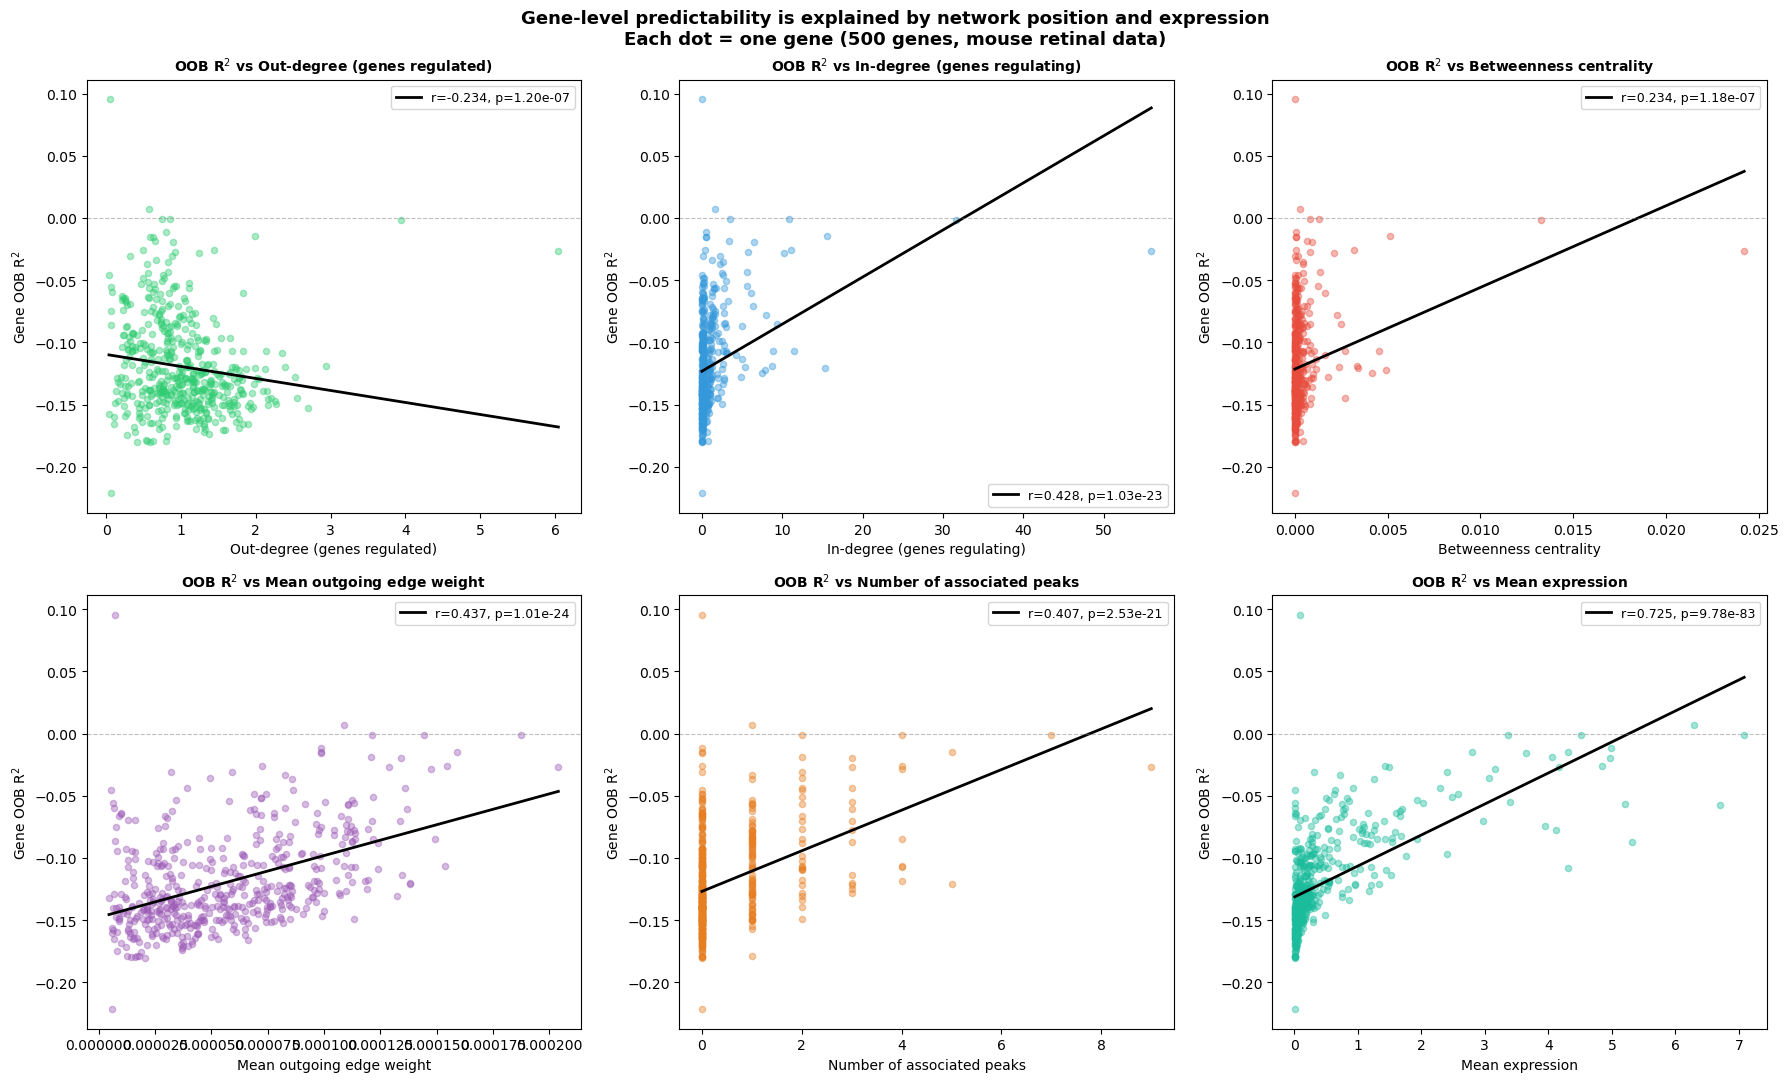

In [110]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

plot_specs = [
    ("out_degree",            "Out-degree (genes regulated)",  "#2ecc71"),
    ("in_degree",              "In-degree (genes regulating)",  "#3498db"),
    ("betweenness",            "Betweenness centrality",        "#e74c3c"),
    ("mean_outgoing_weight",   "Mean outgoing edge weight",     "#9b59b6"),
    ("n_peaks",                "Number of associated peaks",    "#e67e22"),
    ("mean_expr_gene",         "Mean expression",               "#1abc9c"),
]

for ax, (col, label, color) in zip(axes.flat, plot_specs):
    r, p = stats.spearmanr(merged["gene_r2"], merged[col])
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(merged[col], merged["gene_r2"], alpha=0.4, s=20, color=color)

    slope, intercept, _, _, _ = stats.linregress(merged[col], merged["gene_r2"])
    x = np.linspace(merged[col].min(), merged[col].max(), 100)
    ax.plot(x, slope*x + intercept, color="black", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Gene OOB R$^2$", fontsize=10)
    ax.set_title(f"OOB R$^2$ vs {label}", fontweight="bold", fontsize=10)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=9)

fig.suptitle(
    "Gene-level predictability is explained by network position and expression\n"
    "Each dot = one gene (500 genes, mouse retinal data)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("gene_r2_network_position.png", dpi=150, bbox_inches="tight")
plt.show()

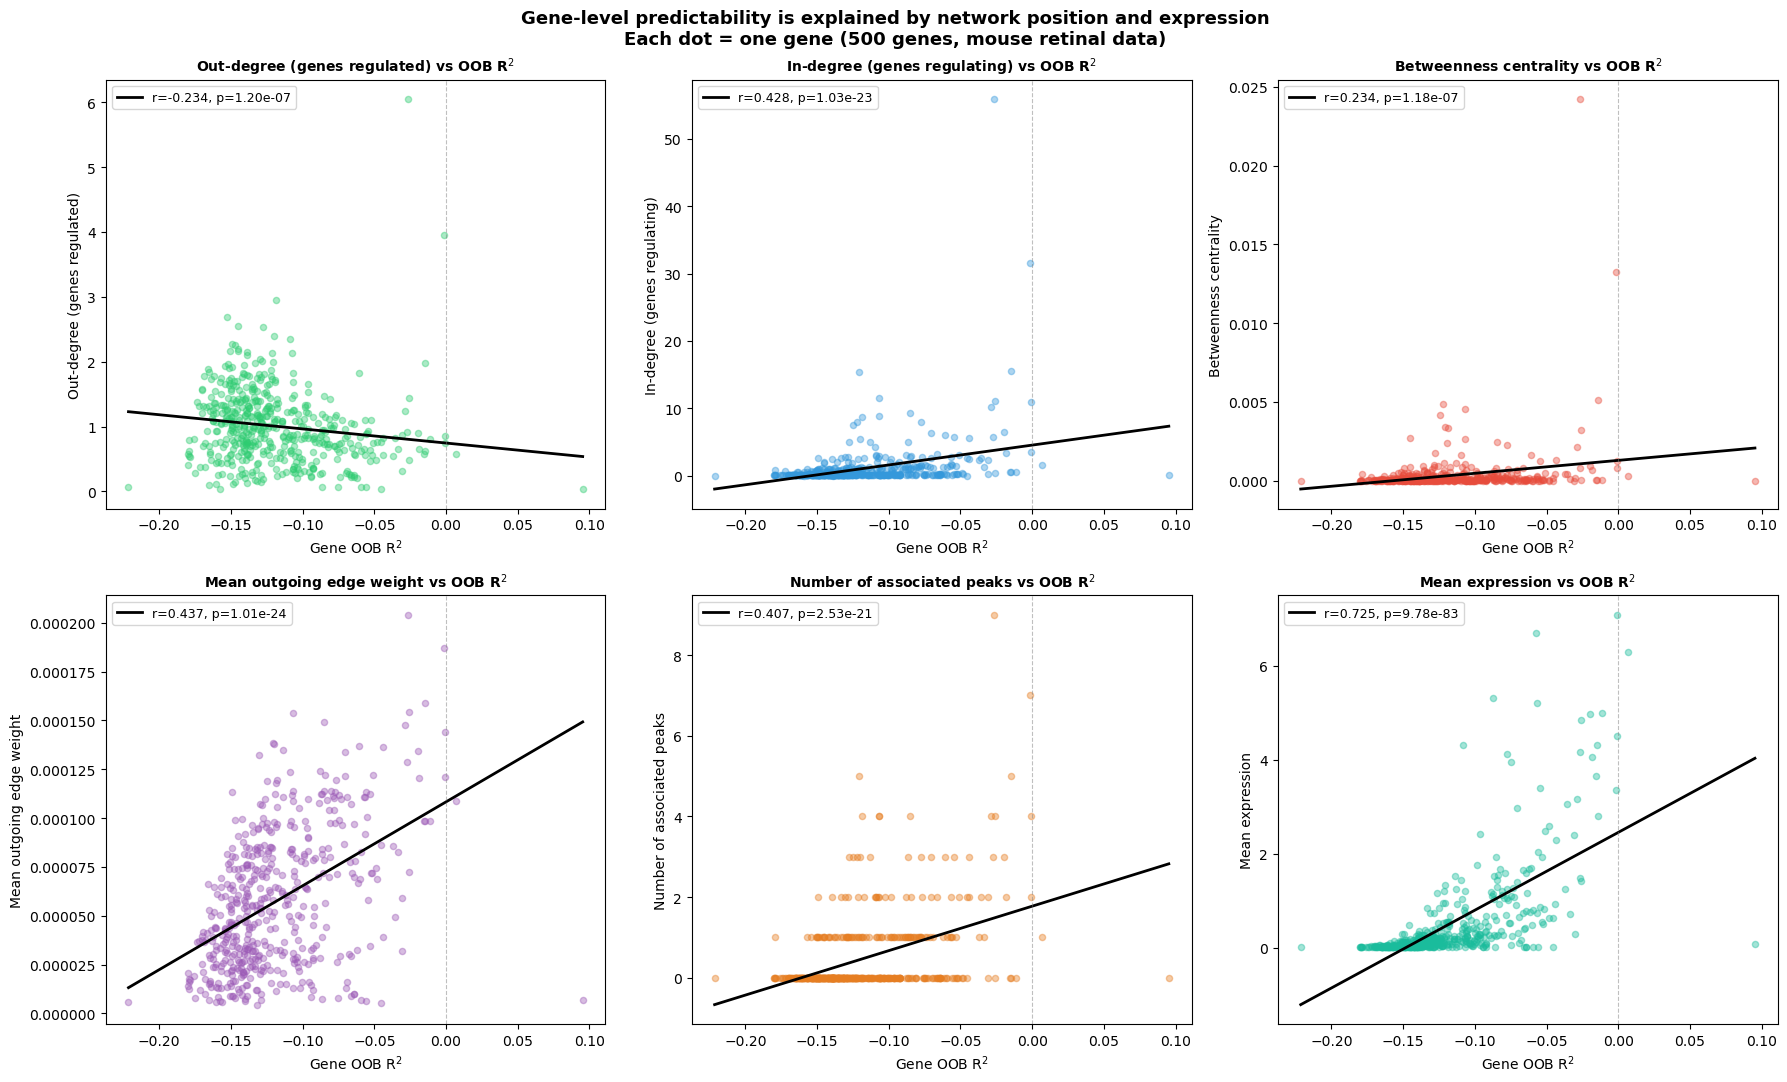

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

plot_specs = [
    ("out_degree",            "Out-degree (genes regulated)",  "#2ecc71"),
    ("in_degree",              "In-degree (genes regulating)",  "#3498db"),
    ("betweenness",            "Betweenness centrality",        "#e74c3c"),
    ("mean_outgoing_weight",   "Mean outgoing edge weight",     "#9b59b6"),
    ("n_peaks",                "Number of associated peaks",    "#e67e22"),
    ("mean_expr_gene",         "Mean expression",               "#1abc9c"),
]

for ax, (col, label, color) in zip(axes.flat, plot_specs):
    r, p = stats.spearmanr(merged["gene_r2"], merged[col])
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(merged["gene_r2"], merged[col], alpha=0.4, s=20, color=color)

    slope, intercept, _, _, _ = stats.linregress(merged["gene_r2"], merged[col])
    x = np.linspace(merged["gene_r2"].min(), merged["gene_r2"].max(), 100)
    ax.plot(x, slope*x + intercept, color="black", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel("Gene OOB R$^2$", fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} vs OOB R$^2$", fontweight="bold", fontsize=10)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=9)

fig.suptitle(
    "Gene-level predictability is explained by network position and expression\n"
    "Each dot = one gene (500 genes, mouse retinal data)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("gene_r2_network_position.png", dpi=150, bbox_inches="tight")
plt.show()

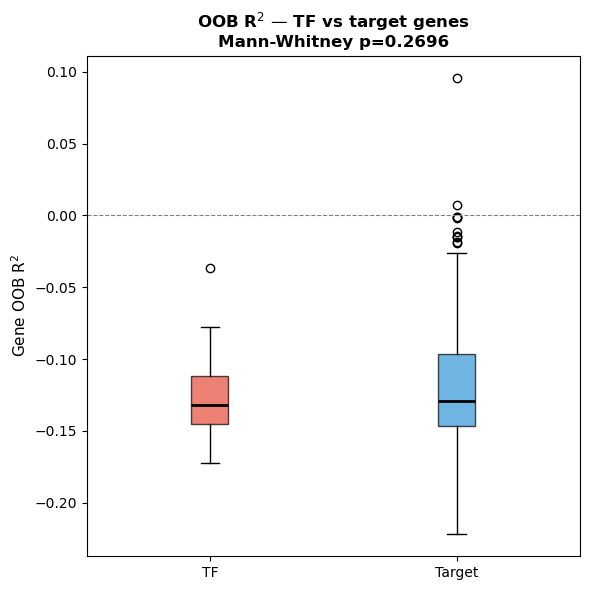

In [112]:
fig, ax = plt.subplots(figsize=(6, 6))

tf_r2     = merged[merged["type"] == "TF"]["gene_r2"]
target_r2 = merged[merged["type"] == "target"]["gene_r2"]
stat, p   = stats.mannwhitneyu(tf_r2, target_r2, alternative="two-sided")
p_str     = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

bp = ax.boxplot([tf_r2, target_r2], tick_labels=["TF", "Target"],
                patch_artist=True,
                boxprops=dict(facecolor="#e74c3c", alpha=0.7),
                medianprops=dict(color="black", linewidth=2))
bp["boxes"][1].set_facecolor("#3498db")

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_ylabel("Gene OOB R$^2$", fontsize=11)
ax.set_title(f"OOB R$^2$ — TF vs target genes\nMann-Whitney p={p_str}", fontweight="bold")
plt.tight_layout()
plt.savefig("gene_r2_tf_vs_target.png", dpi=150)
plt.show()


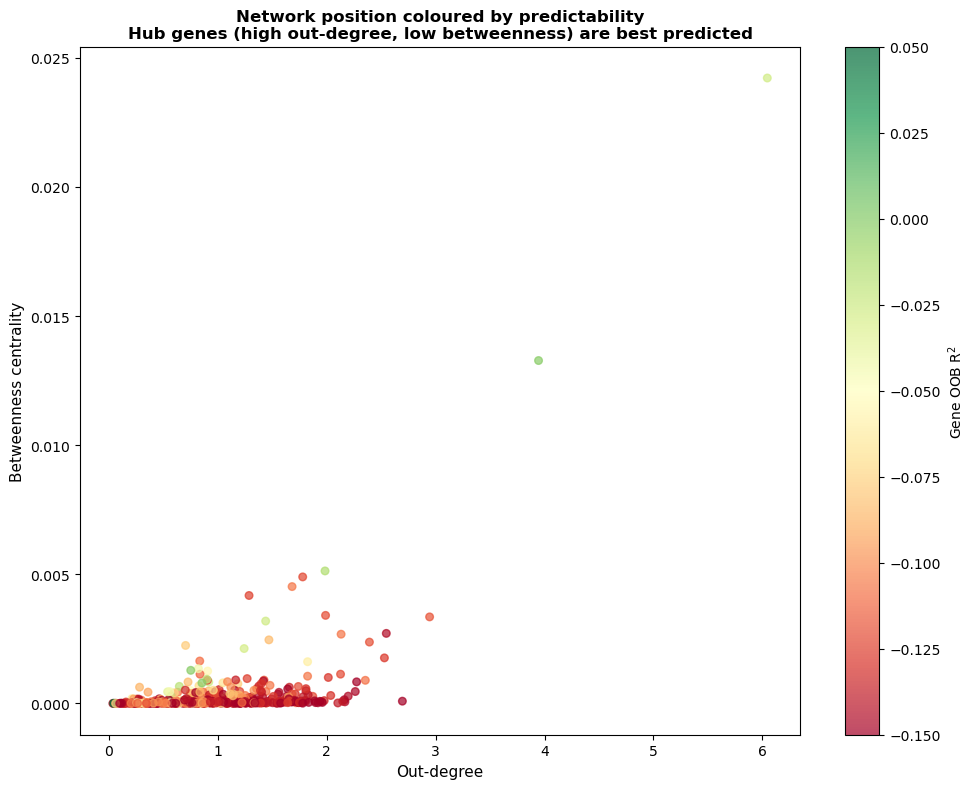

In [113]:
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(merged["out_degree"], merged["betweenness"],
                c=merged["gene_r2"], cmap="RdYlGn", alpha=0.7, s=30,
                vmin=-0.15, vmax=0.05)
plt.colorbar(sc, ax=ax, label="Gene OOB R$^2$")
ax.set_xlabel("Out-degree", fontsize=11)
ax.set_ylabel("Betweenness centrality", fontsize=11)
ax.set_title("Network position coloured by predictability\nHub genes (high out-degree, low betweenness) are best predicted",
             fontweight="bold")
plt.tight_layout()
plt.savefig("gene_r2_hub_vs_bridge.png", dpi=150)
plt.show()

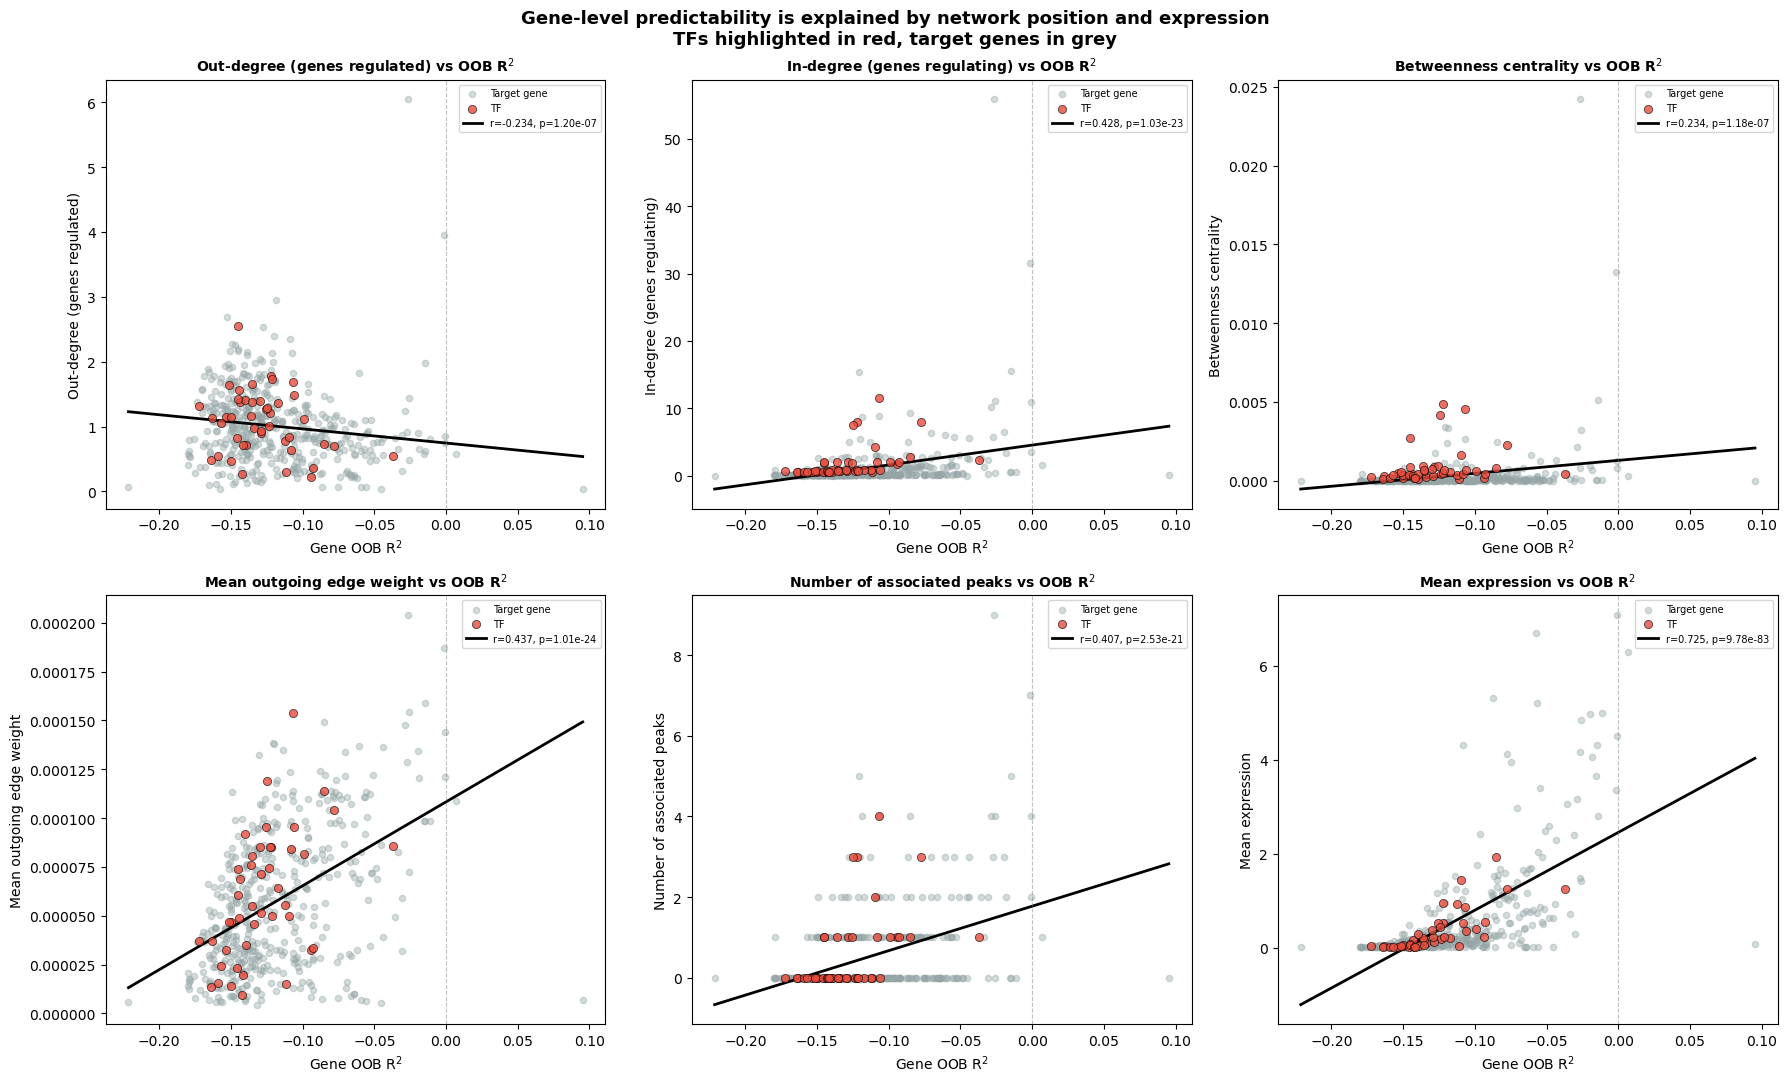

In [114]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

plot_specs = [
    ("out_degree",            "Out-degree (genes regulated)",  "#2ecc71"),
    ("in_degree",              "In-degree (genes regulating)",  "#3498db"),
    ("betweenness",            "Betweenness centrality",        "#e74c3c"),
    ("mean_outgoing_weight",   "Mean outgoing edge weight",     "#9b59b6"),
    ("n_peaks",                "Number of associated peaks",    "#e67e22"),
    ("mean_expr_gene",         "Mean expression",               "#1abc9c"),
]

is_tf = merged["type"] == "TF"

for ax, (col, label, color) in zip(axes.flat, plot_specs):
    r, p = stats.spearmanr(merged["gene_r2"], merged[col])
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(merged.loc[~is_tf, "gene_r2"], merged.loc[~is_tf, col],
               alpha=0.4, s=20, color="#95a5a6", label="Target gene")
    ax.scatter(merged.loc[is_tf, "gene_r2"], merged.loc[is_tf, col],
               alpha=0.8, s=35, color="#e74c3c", edgecolors="black",
               linewidths=0.5, label="TF", zorder=3)

    slope, intercept, _, _, _ = stats.linregress(merged["gene_r2"], merged[col])
    x = np.linspace(merged["gene_r2"].min(), merged["gene_r2"].max(), 100)
    ax.plot(x, slope*x + intercept, color="black", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel("Gene OOB R$^2$", fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} vs OOB R$^2$", fontweight="bold", fontsize=10)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=7)

fig.suptitle(
    "Gene-level predictability is explained by network position and expression\n"
    "TFs highlighted in red, target genes in grey",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("gene_r2_network_position_tf_colored.png", dpi=150, bbox_inches="tight")
plt.show()